### Part 1: Question Formulation


Mixed Martial Arts (MMA) is a dynamic sport with a history dating back to 1992, and over the years, it has evolved significantly. The fundamental concept of MMA is to provide a platform where martial artists from diverse backgrounds can challenge their skills in combat. As the sport has grown in popularity, it has offered insights into the effectiveness of various martial arts disciplines in real combat situations. Through the years the sport has become larger, and as time has gone by certain trends can be seen from following the fights. Following the sport has revealed which martial arts are more effective in actual combat, and as time has progressed there have been more world class athletes in other sports(such as kickboxing, wrestling, combat sambo and jiu jitsu) who have had successful careers in martial arts. One intriguing question emerges from this evolution: What factors are paramount for success in MMA? To begin exploring this question, I intend to conduct an analysis using the UFC dataset available on Kaggle, encompassing fight data from mid 2010 to 2021. This dataset includes comprehensive information, such as takedown percentage, striking accuracy, age, and more, for both the victors and the defeated fighters. I want to analyze the dataset to determine the probability that a fighter will win based on a variety of factors. After cleaning the dataset, I will group the data by fights where the winner has better striking accuracy, where the winner is younger, and various other factors like this. In doing this, I will find the probability of success based on a variety of factors. Additionally, I plan to investigate how these trends have evolved over time, given the sport's increasing popularity, improved MMA training techniques, greater interest from elite athletes in other combat sports, and the sport's expanding global reach.

# Part II: Data Aquisition and Cleaning


In [ ]:
import pandas as pd

In [ ]:
df = pd.read_csv("ufc-master.csv")

In [ ]:
df.head()

,R_fighter,B_fighter,R_odds,B_odds,R_ev,B_ev,date,location,country,Winner,...,finish_details,finish_round,finish_round_time,total_fight_time_secs,r_dec_odds,b_dec_odds,r_sub_odds,b_sub_odds,r_ko_odds,b_ko_odds
0,Thiago Santos,Johnny Walker,-150.0,130,66.666667,130.000000,2021-10-02,"Las Vegas, Nevada, USA",USA,Red,...,NaN,5.0,5:00,1500.0,800.0,900.0,2000.0,1600.0,-110.0,175.0
1,Alex Oliveira,Niko Price,170.0,-200,170.000000,50.000000,2021-10-02,"Las Vegas, Nevada, USA",USA,Blue,...,NaN,3.0,5:00,900.0,450.0,350.0,700.0,1100.0,550.0,120.0
2,Misha Cirkunov,Krzysztof Jotko,110.0,-130,110.000000,76.923077,2021-10-02,"Las Vegas, Nevada, USA",USA,Blue,...,NaN,3.0,5:00,900.0,550.0,275.0,275.0,1400.0,600.0,185.0
3,Alexander Hernandez,Mike Breeden,-675.0,475,14.814815,475.000000,2021-10-02,"Las Vegas, Nevada, USA",USA,Red,...,Punch,1.0,1:20,80.0,175.0,900.0,500.0,3500.0,110.0,1100.0
4,Joe Solecki,Jared Gordon,-135.0,115,74.074074,115.000000,2021-10-02,"Las Vegas, Nevada, USA",USA,Blue,...,NaN,3.0,5:00,900.0,165.0,200.0,400.0,1200.0,900.0,600.0


In [ ]:
df

,R_fighter,B_fighter,R_odds,B_odds,R_ev,B_ev,date,location,country,Winner,...,finish_details,finish_round,finish_round_time,total_fight_time_secs,r_dec_odds,b_dec_odds,r_sub_odds,b_sub_odds,r_ko_odds,b_ko_odds
0,Thiago Santos,Johnny Walker,-150.0,130,66.666667,130.000000,2021-10-02,"Las Vegas, Nevada, USA",USA,Red,...,NaN,5.0,5:00,1500.0,800.0,900.0,2000.0,1600.0,-110.0,175.0
1,Alex Oliveira,Niko Price,170.0,-200,170.000000,50.000000,2021-10-02,"Las Vegas, Nevada, USA",USA,Blue,...,NaN,3.0,5:00,900.0,450.0,350.0,700.0,1100.0,550.0,120.0
2,Misha Cirkunov,Krzysztof Jotko,110.0,-130,110.000000,76.923077,2021-10-02,"Las Vegas, Nevada, USA",USA,Blue,...,NaN,3.0,5:00,900.0,550.0,275.0,275.0,1400.0,600.0,185.0
3,Alexander Hernandez,Mike Breeden,-675.0,475,14.814815,475.000000,2021-10-02,"Las Vegas, Nevada, USA",USA,Red,...,Punch,1.0,1:20,80.0,175.0,900.0,500.0,3500.0,110.0,1100.0
4,Joe Solecki,Jared Gordon,-135.0,115,74.074074,115.000000,2021-10-02,"Las Vegas, Nevada, USA",USA,Blue,...,NaN,3.0,5:00,900.0,165.0,200.0,400.0,1200.0,900.0,600.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4891,Duane Ludwig,Darren Elkins,-155.0,135,64.516129,135.000000,3/21/2010,"Broomfield, Colorado, USA",USA,Blue,...,NaN,1.0,0:44,44.0,NaN,NaN,NaN,NaN,NaN,NaN
4892,John Howard,Daniel Roberts,-210.0,175,47.619048,175.000000,3/21/2010,"Broomfield, Colorado, USA",USA,Red,...,Punch,1.0,2:01,121.0,NaN,NaN,NaN,NaN,NaN,NaN
4893,Brendan Schaub,Chase Gormley,-260.0,220,38.461538,220.000000,3/21/2010,"Broomfield, Colorado, USA",USA,Red,...,Punches,1.0,0:47,47.0,NaN,NaN,NaN,NaN,NaN,NaN
4894,Mike Pierce,Julio Paulino,-420.0,335,23.809524,335.000000,3/21/2010,"Broomfield, Colorado, USA",USA,Red,...,NaN,3.0,5:00,900.0,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
#see all of the columns
df.columns

Index(['R_fighter', 'B_fighter', 'R_odds', 'B_odds', 'R_ev', 'B_ev', 'date',
       'location', 'country', 'Winner',
       ...
       'finish_details', 'finish_round', 'finish_round_time',
       'total_fight_time_secs', 'r_dec_odds', 'b_dec_odds', 'r_sub_odds',
       'b_sub_odds', 'r_ko_odds', 'b_ko_odds'],
      dtype='object', length=119)

In [ ]:
#there are a lot of columns. The following will help us see ALL of the columns.
for col in df.columns:
    print(col)

R_fighter
B_fighter
R_odds
B_odds
R_ev
B_ev
date
location
country
Winner
title_bout
weight_class
gender
no_of_rounds
B_current_lose_streak
B_current_win_streak
B_draw
B_avg_SIG_STR_landed
B_avg_SIG_STR_pct
B_avg_SUB_ATT
B_avg_TD_landed
B_avg_TD_pct
B_longest_win_streak
B_losses
B_total_rounds_fought
B_total_title_bouts
B_win_by_Decision_Majority
B_win_by_Decision_Split
B_win_by_Decision_Unanimous
B_win_by_KO/TKO
B_win_by_Submission
B_win_by_TKO_Doctor_Stoppage
B_wins
B_Stance
B_Height_cms
B_Reach_cms
B_Weight_lbs
R_current_lose_streak
R_current_win_streak
R_draw
R_avg_SIG_STR_landed
R_avg_SIG_STR_pct
R_avg_SUB_ATT
R_avg_TD_landed
R_avg_TD_pct
R_longest_win_streak
R_losses
R_total_rounds_fought
R_total_title_bouts
R_win_by_Decision_Majority
R_win_by_Decision_Split
R_win_by_Decision_Unanimous
R_win_by_KO/TKO
R_win_by_Submission
R_win_by_TKO_Doctor_Stoppage
R_wins
R_Stance
R_Height_cms
R_Reach_cms
R_Weight_lbs
R_age
B_age
lose_streak_dif
win_streak_dif
longest_win_streak_dif
win_dif
loss_

I am only interested in the stats on each fighter when doing my analysis. Columns with information like rankings, odds, and location are due to outside influences like rankings commitees and oddsmakers. In order to perform a data analysis on what factors of a fighter's own fight statistics are paramount for success, I will drop the columns on rankings and odds.

In [ ]:
#Dropping betting odds columns
df.drop('b_ko_odds', axis=1, inplace=True)
df.drop('r_ko_odds', axis=1, inplace=True)
df.drop('b_sub_odds', axis=1, inplace=True)

df.drop('r_sub_odds', axis=1, inplace=True)
df.drop('r_dec_odds', axis=1, inplace=True)
df.drop('b_dec_odds', axis=1, inplace=True)
df.drop('B_odds', axis=1, inplace=True)
df.drop('R_odds', axis=1, inplace=True)
df.drop('B_ev', axis=1, inplace=True)
df.drop('R_ev', axis=1, inplace=True)

In [ ]:
for col in df.columns:
    print(col)

R_fighter
B_fighter
date
location
country
Winner
title_bout
weight_class
gender
no_of_rounds
B_current_lose_streak
B_current_win_streak
B_draw
B_avg_SIG_STR_landed
B_avg_SIG_STR_pct
B_avg_SUB_ATT
B_avg_TD_landed
B_avg_TD_pct
B_longest_win_streak
B_losses
B_total_rounds_fought
B_total_title_bouts
B_win_by_Decision_Majority
B_win_by_Decision_Split
B_win_by_Decision_Unanimous
B_win_by_KO/TKO
B_win_by_Submission
B_win_by_TKO_Doctor_Stoppage
B_wins
B_Stance
B_Height_cms
B_Reach_cms
B_Weight_lbs
R_current_lose_streak
R_current_win_streak
R_draw
R_avg_SIG_STR_landed
R_avg_SIG_STR_pct
R_avg_SUB_ATT
R_avg_TD_landed
R_avg_TD_pct
R_longest_win_streak
R_losses
R_total_rounds_fought
R_total_title_bouts
R_win_by_Decision_Majority
R_win_by_Decision_Split
R_win_by_Decision_Unanimous
R_win_by_KO/TKO
R_win_by_Submission
R_win_by_TKO_Doctor_Stoppage
R_wins
R_Stance
R_Height_cms
R_Reach_cms
R_Weight_lbs
R_age
B_age
lose_streak_dif
win_streak_dif
longest_win_streak_dif
win_dif
loss_dif
total_round_dif
tota

In [ ]:
#Dropping rankings columns
df.drop('B_match_weightclass_rank', axis=1, inplace=True)
df.drop('R_match_weightclass_rank', axis=1, inplace=True)

df.drop('R_Heavyweight_rank', axis=1, inplace=True)
df.drop('R_Light Heavyweight_rank', axis=1, inplace=True)
df.drop('R_Middleweight_rank', axis=1, inplace=True)
df.drop('R_Welterweight_rank', axis=1, inplace=True)
df.drop('R_Lightweight_rank', axis=1, inplace=True)
df.drop('R_Featherweight_rank', axis=1, inplace=True)
df.drop('R_Bantamweight_rank', axis=1, inplace=True)
df.drop('R_Flyweight_rank', axis=1, inplace=True)
df.drop('R_Pound-for-Pound_rank', axis=1, inplace=True)
df.drop('B_Heavyweight_rank', axis=1, inplace=True)
df.drop('B_Light Heavyweight_rank', axis=1, inplace=True)
df.drop('B_Middleweight_rank', axis=1, inplace=True)
df.drop('B_Welterweight_rank', axis=1, inplace=True)
df.drop('B_Lightweight_rank', axis=1, inplace=True)
df.drop('B_Featherweight_rank', axis=1, inplace=True)
df.drop('B_Bantamweight_rank', axis=1, inplace=True)
df.drop('B_Flyweight_rank', axis=1, inplace=True)
df.drop('B_Pound-for-Pound_rank', axis=1, inplace=True)

df.drop(["R_Women's Flyweight_rank"], axis=1, inplace=True)
df.drop(["R_Women's Featherweight_rank"], axis=1, inplace=True)
df.drop(["R_Women's Strawweight_rank"], axis=1, inplace=True)
df.drop(["R_Women's Bantamweight_rank"], axis=1, inplace=True)
df.drop(["B_Women's Flyweight_rank"], axis=1, inplace=True)
df.drop(["B_Women's Featherweight_rank"], axis=1, inplace=True)
df.drop(["B_Women's Strawweight_rank"], axis=1, inplace=True)
df.drop(["B_Women's Bantamweight_rank"], axis=1, inplace=True)

In [ ]:
for col in df.columns:
    print(col)

R_fighter
B_fighter
date
location
country
Winner
title_bout
weight_class
gender
no_of_rounds
B_current_lose_streak
B_current_win_streak
B_draw
B_avg_SIG_STR_landed
B_avg_SIG_STR_pct
B_avg_SUB_ATT
B_avg_TD_landed
B_avg_TD_pct
B_longest_win_streak
B_losses
B_total_rounds_fought
B_total_title_bouts
B_win_by_Decision_Majority
B_win_by_Decision_Split
B_win_by_Decision_Unanimous
B_win_by_KO/TKO
B_win_by_Submission
B_win_by_TKO_Doctor_Stoppage
B_wins
B_Stance
B_Height_cms
B_Reach_cms
B_Weight_lbs
R_current_lose_streak
R_current_win_streak
R_draw
R_avg_SIG_STR_landed
R_avg_SIG_STR_pct
R_avg_SUB_ATT
R_avg_TD_landed
R_avg_TD_pct
R_longest_win_streak
R_losses
R_total_rounds_fought
R_total_title_bouts
R_win_by_Decision_Majority
R_win_by_Decision_Split
R_win_by_Decision_Unanimous
R_win_by_KO/TKO
R_win_by_Submission
R_win_by_TKO_Doctor_Stoppage
R_wins
R_Stance
R_Height_cms
R_Reach_cms
R_Weight_lbs
R_age
B_age
lose_streak_dif
win_streak_dif
longest_win_streak_dif
win_dif
loss_dif
total_round_dif
tota

There can probably be an entire different project dedicated to finding the differences between Men's and Women's MMA. However, since the majority of MMA fights are men's, and women's MMA is relatively new, for this project I will stick to analyzing trends in men's MMA.

In [ ]:
#Here we can see the total number of fights where gender is Male, and where it is Female
print('Total Male fights: ' + str((df['gender'] == 'MALE').sum()))
print('Total Female fights: ' + str((df['gender'] != 'MALE').sum()))

Total Male fights: 4384
Total Female fights: 512


In [ ]:
#have df only contain male fights
df = df[df['gender'] == 'MALE']
df

,R_fighter,B_fighter,date,location,country,Winner,title_bout,weight_class,gender,no_of_rounds,...,avg_sub_att_dif,avg_td_dif,empty_arena,constant_1,better_rank,finish,finish_details,finish_round,finish_round_time,total_fight_time_secs
0,Thiago Santos,Johnny Walker,2021-10-02,"Las Vegas, Nevada, USA",USA,Red,False,Light Heavyweight,MALE,5,...,0.600000,-0.370000,1,1,Red,U-DEC,NaN,5.0,5:00,1500.0
1,Alex Oliveira,Niko Price,2021-10-02,"Las Vegas, Nevada, USA",USA,Blue,False,Welterweight,MALE,3,...,0.300000,-1.480000,1,1,neither,U-DEC,NaN,3.0,5:00,900.0
2,Misha Cirkunov,Krzysztof Jotko,2021-10-02,"Las Vegas, Nevada, USA",USA,Blue,False,Middleweight,MALE,3,...,-1.600000,-3.330000,1,1,neither,S-DEC,NaN,3.0,5:00,900.0
3,Alexander Hernandez,Mike Breeden,2021-10-02,"Las Vegas, Nevada, USA",USA,Red,False,Lightweight,MALE,3,...,0.000000,-1.570000,1,1,neither,KO/TKO,Punch,1.0,1:20,80.0
4,Joe Solecki,Jared Gordon,2021-10-02,"Las Vegas, Nevada, USA",USA,Blue,False,Lightweight,MALE,3,...,-0.600000,-0.310000,1,1,neither,S-DEC,NaN,3.0,5:00,900.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4891,Duane Ludwig,Darren Elkins,3/21/2010,"Broomfield, Colorado, USA",USA,Blue,False,Lightweight,MALE,3,...,0.000000,0.000000,0,1,neither,KO/TKO,NaN,1.0,0:44,44.0
4892,John Howard,Daniel Roberts,3/21/2010,"Broomfield, Colorado, USA",USA,Red,False,Welterweight,MALE,3,...,-1.000000,-4.666667,0,1,neither,KO/TKO,Punch,1.0,2:01,121.0
4893,Brendan Schaub,Chase Gormley,3/21/2010,"Broomfield, Colorado, USA",USA,Red,False,Heavyweight,MALE,3,...,1.000000,1.000000,0,1,neither,KO/TKO,Punches,1.0,0:47,47.0
4894,Mike Pierce,Julio Paulino,3/21/2010,"Broomfield, Colorado, USA",USA,Red,False,Welterweight,MALE,3,...,0.000000,-3.500000,0,1,neither,U-DEC,NaN,3.0,5:00,900.0


In [ ]:
#dropping various other columns that aren't related to the stats on each fighter
df.drop('total_fight_time_secs', axis=1, inplace=True)
df.drop('finish_round_time', axis=1, inplace=True)
df.drop('finish_round', axis=1, inplace=True)

df.drop('finish_details', axis=1, inplace=True)
df.drop('empty_arena', axis=1, inplace=True)
df.drop('location', axis=1, inplace=True)
df.drop('country', axis=1, inplace=True)
df.drop('gender', axis=1, inplace=True)

<ipython-input-13-008750181bad>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.drop('total_fight_time_secs', axis=1, inplace=True)
<ipython-input-13-008750181bad>:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.drop('finish_round_time', axis=1, inplace=True)
<ipython-input-13-008750181bad>:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.drop('finish_round', axis=1, inplace=True)
<ipython-input-13-008750181bad>:6: SettingWi

In [ ]:
for col in df.columns:
    print(col)

R_fighter
B_fighter
date
Winner
title_bout
weight_class
no_of_rounds
B_current_lose_streak
B_current_win_streak
B_draw
B_avg_SIG_STR_landed
B_avg_SIG_STR_pct
B_avg_SUB_ATT
B_avg_TD_landed
B_avg_TD_pct
B_longest_win_streak
B_losses
B_total_rounds_fought
B_total_title_bouts
B_win_by_Decision_Majority
B_win_by_Decision_Split
B_win_by_Decision_Unanimous
B_win_by_KO/TKO
B_win_by_Submission
B_win_by_TKO_Doctor_Stoppage
B_wins
B_Stance
B_Height_cms
B_Reach_cms
B_Weight_lbs
R_current_lose_streak
R_current_win_streak
R_draw
R_avg_SIG_STR_landed
R_avg_SIG_STR_pct
R_avg_SUB_ATT
R_avg_TD_landed
R_avg_TD_pct
R_longest_win_streak
R_losses
R_total_rounds_fought
R_total_title_bouts
R_win_by_Decision_Majority
R_win_by_Decision_Split
R_win_by_Decision_Unanimous
R_win_by_KO/TKO
R_win_by_Submission
R_win_by_TKO_Doctor_Stoppage
R_wins
R_Stance
R_Height_cms
R_Reach_cms
R_Weight_lbs
R_age
B_age
lose_streak_dif
win_streak_dif
longest_win_streak_dif
win_dif
loss_dif
total_round_dif
total_title_bout_dif
ko_dif


In [ ]:
df.describe()

,no_of_rounds,B_current_lose_streak,B_current_win_streak,B_draw,B_avg_SIG_STR_landed,B_avg_SIG_STR_pct,B_avg_SUB_ATT,B_avg_TD_landed,B_avg_TD_pct,B_longest_win_streak,...,total_title_bout_dif,ko_dif,sub_dif,height_dif,reach_dif,age_dif,sig_str_dif,avg_sub_att_dif,avg_td_dif,constant_1
count,4384.000000,4384.000000,4384.000000,4384.000000,3565.000000,3704.000000,3647.000000,3646.000000,3639.000000,4384.000000,...,4384.000000,4384.000000,4384.000000,4384.000000,4384.000000,4384.000000,4384.000000,4384.000000,4384.000000,4384.0
mean,3.179060,0.483349,0.890967,0.009352,26.138548,0.444882,0.505439,1.264814,0.307471,1.823221,...,-0.317062,-0.538093,-0.296533,0.100716,-0.193198,0.392792,-3.532146,-0.063158,-0.201522,1.0
std,0.567272,0.775625,1.336229,0.100893,19.773211,0.120836,0.675862,1.348724,0.243362,1.925962,...,1.677874,2.168976,1.827023,7.014583,9.287912,5.143472,21.856345,0.848921,1.714713,0.0
min,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,-16.000000,-21.000000,-13.000000,-187.960000,-187.960000,-17.000000,-113.000000,-8.300000,-11.000000,1.0
25%,3.000000,0.000000,0.000000,0.000000,7.000000,0.388274,0.000000,0.250000,0.110000,0.000000,...,0.000000,-1.000000,-1.000000,-5.080000,-5.080000,-3.000000,-15.000000,-0.416667,-1.000000,1.0
50%,3.000000,0.000000,0.000000,0.000000,25.000000,0.450000,0.300000,1.000000,0.307500,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-0.880000,0.000000,0.000000,1.0
75%,3.000000,1.000000,1.000000,0.000000,38.500000,0.510000,0.800000,1.850000,0.456307,3.000000,...,0.000000,0.000000,0.000000,5.080000,5.080000,4.000000,5.310606,0.250000,0.601786,1.0
max,5.000000,6.000000,12.000000,2.000000,154.000000,1.000000,7.000000,10.860000,1.000000,17.000000,...,14.000000,14.000000,10.000000,30.480000,30.480000,17.000000,128.222222,6.000000,10.860000,1.0


Now that we have the columns we want, lets see the variable type of each column

In [ ]:

for col in df.columns:
    print(str(col) + ': ' + str(df[col].dtype))

R_fighter: object
B_fighter: object
date: object
Winner: object
title_bout: bool
weight_class: object
no_of_rounds: int64
B_current_lose_streak: int64
B_current_win_streak: int64
B_draw: int64
B_avg_SIG_STR_landed: float64
B_avg_SIG_STR_pct: float64
B_avg_SUB_ATT: float64
B_avg_TD_landed: float64
B_avg_TD_pct: float64
B_longest_win_streak: int64
B_losses: int64
B_total_rounds_fought: int64
B_total_title_bouts: int64
B_win_by_Decision_Majority: int64
B_win_by_Decision_Split: int64
B_win_by_Decision_Unanimous: int64
B_win_by_KO/TKO: int64
B_win_by_Submission: int64
B_win_by_TKO_Doctor_Stoppage: int64
B_wins: int64
B_Stance: object
B_Height_cms: float64
B_Reach_cms: float64
B_Weight_lbs: int64
R_current_lose_streak: int64
R_current_win_streak: int64
R_draw: int64
R_avg_SIG_STR_landed: float64
R_avg_SIG_STR_pct: float64
R_avg_SUB_ATT: float64
R_avg_TD_landed: float64
R_avg_TD_pct: float64
R_longest_win_streak: int64
R_losses: int64
R_total_rounds_fought: int64
R_total_title_bouts: int64
R_

I notice that the date column is an object, but performing data analysis may be easier if I convert it to a datetime object.

In [ ]:
df['date'].head()

0    2021-10-02
1    2021-10-02
2    2021-10-02
3    2021-10-02
4    2021-10-02
Name: date, dtype: object

In [ ]:
#df['date'] = pd.to_datetime(df['date'])
df['date'].head()

0    2021-10-02
1    2021-10-02
2    2021-10-02
3    2021-10-02
4    2021-10-02
Name: date, dtype: object

In [ ]:
#we can see why this is an object because it contains a string
df['better_rank'].head()

0        Red
1    neither
2    neither
3    neither
4    neither
Name: better_rank, dtype: object

I will next limit the dataset down to the number of records where there is a winner. This is because the number of times a bout ends in a draw or no contest is so small that in my opinion, it doesn't necassarily show us useful information on what factors influence success.


In [ ]:
df['Winner'].head()

0     Red
1    Blue
2    Blue
3     Red
4    Blue
Name: Winner, dtype: object

In [ ]:
#print number of rows where there is a winner
print(((df['Winner'] == 'Blue') | (df['Winner'] == 'Red')).sum())

4384


In [ ]:
#prints number of rows where there isnt a winner. This returns zero, so it seems whoever put the dataset together already removed the rows
#where there is a draw or no contest.
print((~df['Winner'].isin(['Blue', 'Red'])).sum())

0


We have broken our dataset down to include only the variables we're interested in, and have limited the dataset to include male fights. We have also converted the date column to a datetime object. By looking at the columns, we can see that the variable types are what is expected for each.
We have qualitative nominal data(fighter names, stance, etc), though most of our data is quantitative discrete, since they're fixed data points on each fighter going into each fight. The structure of the data must be noted, because the winner is noted by the 'Winner' column, meaning there are times when the blue figther wins and times where the red fighter wins. Because of this, it may be a bit challenging doing visualizations that show trends for winners.

To account for the structure of the data, I'm going to make new columns. In these columns, I'll put the technical stats of the winner of each fight. To do this, I'll select the data conditionally using lambda.


In [ ]:
#look at the winner for the first five rows
df['Winner'].head()

0     Red
1    Blue
2    Blue
3     Red
4    Blue
Name: Winner, dtype: object

In [ ]:
#look at the first five rows of Blue's average takedown percentage
df['B_avg_TD_pct'].head()

0    1.00
1    0.22
2    0.34
3    0.00
4    0.39
Name: B_avg_TD_pct, dtype: float64

In [ ]:
#look at the first five rows of Red's average takedown percentage
df['R_avg_TD_pct'].head()

0    0.36
1    0.37
2    0.44
3    0.35
4    0.52
Name: R_avg_TD_pct, dtype: float64

In [ ]:
#apply this fuction to a new column conditionally on whether the winner is Blue or Red
df['Avg_TD_pct_Winner'] = df.apply(lambda row: row['B_avg_TD_pct'] if row['Winner'] == 'Blue' else row['R_avg_TD_pct'], axis=1)
df['Avg_TD_pct_Loser'] = df.apply(lambda row: row['B_avg_TD_pct'] if row['Winner'] != 'Blue' else row['R_avg_TD_pct'], axis=1)
#By looking at this and the series above, we see that it applies to the winners
df['Avg_TD_pct_Winner'].head()

<ipython-input-26-9468ffd52163>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Avg_TD_pct_Winner'] = df.apply(lambda row: row['B_avg_TD_pct'] if row['Winner'] == 'Blue' else row['R_avg_TD_pct'], axis=1)
<ipython-input-26-9468ffd52163>:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Avg_TD_pct_Loser'] = df.apply(lambda row: row['B_avg_TD_pct'] if row['Winner'] != 'Blue' else row['R_avg_TD_pct'], axis=1)


0    0.36
1    0.22
2    0.34
3    0.35
4    0.39
Name: Avg_TD_pct_Winner, dtype: float64

In [ ]:
for col in df.columns:
    print(col)

R_fighter
B_fighter
date
Winner
title_bout
weight_class
no_of_rounds
B_current_lose_streak
B_current_win_streak
B_draw
B_avg_SIG_STR_landed
B_avg_SIG_STR_pct
B_avg_SUB_ATT
B_avg_TD_landed
B_avg_TD_pct
B_longest_win_streak
B_losses
B_total_rounds_fought
B_total_title_bouts
B_win_by_Decision_Majority
B_win_by_Decision_Split
B_win_by_Decision_Unanimous
B_win_by_KO/TKO
B_win_by_Submission
B_win_by_TKO_Doctor_Stoppage
B_wins
B_Stance
B_Height_cms
B_Reach_cms
B_Weight_lbs
R_current_lose_streak
R_current_win_streak
R_draw
R_avg_SIG_STR_landed
R_avg_SIG_STR_pct
R_avg_SUB_ATT
R_avg_TD_landed
R_avg_TD_pct
R_longest_win_streak
R_losses
R_total_rounds_fought
R_total_title_bouts
R_win_by_Decision_Majority
R_win_by_Decision_Split
R_win_by_Decision_Unanimous
R_win_by_KO/TKO
R_win_by_Submission
R_win_by_TKO_Doctor_Stoppage
R_wins
R_Stance
R_Height_cms
R_Reach_cms
R_Weight_lbs
R_age
B_age
lose_streak_dif
win_streak_dif
longest_win_streak_dif
win_dif
loss_dif
total_round_dif
total_title_bout_dif
ko_dif


Here we will make more columns similarly, putting the data for the winners into their own columns

In [ ]:
df['current_lose_streak_Winner'] = df.apply(lambda row: row['B_current_lose_streak'] if row['Winner'] == 'Blue' else row['R_current_lose_streak'], axis=1)
df['current_win_streak_Winner'] = df.apply(lambda row: row['B_current_win_streak'] if row['Winner'] == 'Blue' else row['R_current_win_streak'], axis=1)
df['draw_Winner'] = df.apply(lambda row: row['B_draw'] if row['Winner'] == 'Blue' else row['R_draw'], axis=1)
df['avg_SIG_STR_landed_Winner'] = df.apply(lambda row: row['B_avg_SIG_STR_landed'] if row['Winner'] == 'Blue' else row['R_avg_SIG_STR_landed'], axis=1)
df['avg_SIG_STR_pct_Winner'] = df.apply(lambda row: row['B_avg_SIG_STR_pct'] if row['Winner'] == 'Blue' else row['R_avg_SIG_STR_pct'], axis=1)
df['avg_SUB_ATT_Winner'] = df.apply(lambda row: row['B_avg_SUB_ATT'] if row['Winner'] == 'Blue' else row['R_avg_SUB_ATT'], axis=1)
df['avg_TD_landed_Winner'] = df.apply(lambda row: row['B_avg_TD_landed'] if row['Winner'] == 'Blue' else row['R_avg_TD_landed'], axis=1)
df['longest_win_streak_Winner'] = df.apply(lambda row: row['B_longest_win_streak'] if row['Winner'] == 'Blue' else row['R_longest_win_streak'], axis=1)
df['losses_Winner'] = df.apply(lambda row: row['B_losses'] if row['Winner'] == 'Blue' else row['R_losses'], axis=1)
df['total_rounds_fought_Winner'] = df.apply(lambda row: row['B_total_rounds_fought'] if row['Winner'] == 'Blue' else row['R_total_rounds_fought'], axis=1)
df['total_title_bouts_Winner'] = df.apply(lambda row: row['B_total_title_bouts'] if row['Winner'] == 'Blue' else row['R_total_title_bouts'], axis=1)
df['wins_Winner'] = df.apply(lambda row: row['B_wins'] if row['Winner'] == 'Blue' else row['R_wins'], axis=1)
df['Stance_Winner'] = df.apply(lambda row: row['B_Stance'] if row['Winner'] == 'Blue' else row['R_Stance'], axis=1)
df['Height_cms_Winner'] = df.apply(lambda row: row['B_Height_cms'] if row['Winner'] == 'Blue' else row['R_Height_cms'], axis=1)
df['Weight_lbs_Winner'] = df.apply(lambda row: row['B_Weight_lbs'] if row['Winner'] == 'Blue' else row['R_Weight_lbs'], axis=1)
df['Reach_Winner'] = df.apply(lambda row: row['B_Reach_cms'] if row['Winner'] == 'Blue' else row['R_Reach_cms'], axis=1)
df['age_Winner'] = df.apply(lambda row: row['B_age'] if row['Winner'] == 'Blue' else row['R_age'], axis=1)
df['win_by_KO/TKO_Winner'] = df.apply(lambda row: row['B_win_by_KO/TKO'] if row['Winner'] == 'Blue' else row['R_win_by_KO/TKO'], axis=1)
df['win_by_Submission_Winner'] = df.apply(lambda row: row['B_win_by_Submission'] if row['Winner'] == 'Blue' else row['R_win_by_Submission'], axis=1)
df['B_total_finishes'] = df['B_win_by_KO/TKO'] + df['B_win_by_Submission']
df['R_total_finishes'] = df['R_win_by_KO/TKO'] + df['R_win_by_Submission']
df['total_finished_winner'] = df.apply(lambda row: row['B_total_finishes'] if row['Winner'] == 'Blue' else row['R_total_finishes'], axis=1)

<ipython-input-28-127c9b6c4cfa>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['current_lose_streak_Winner'] = df.apply(lambda row: row['B_current_lose_streak'] if row['Winner'] == 'Blue' else row['R_current_lose_streak'], axis=1)
<ipython-input-28-127c9b6c4cfa>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['current_win_streak_Winner'] = df.apply(lambda row: row['B_current_win_streak'] if row['Winner'] == 'Blue' else row['R_current_win_streak'], axis=1)
<ipython-input-28-127c9b6c4cfa>:3: SettingW

Now we will do the same thing for the losers of each fight.

In [ ]:
df['current_lose_streak_Loser'] = df.apply(lambda row: row['B_current_lose_streak'] if row['Winner'] != 'Blue' else row['R_current_lose_streak'], axis=1)
df['current_win_streak_Loser'] = df.apply(lambda row: row['B_current_win_streak'] if row['Winner'] != 'Blue' else row['R_current_win_streak'], axis=1)
df['draw_Loser'] = df.apply(lambda row: row['B_draw'] if row['Winner'] != 'Blue' else row['R_draw'], axis=1)
df['avg_SIG_STR_landed_Loser'] = df.apply(lambda row: row['B_avg_SIG_STR_landed'] if row['Winner'] != 'Blue' else row['R_avg_SIG_STR_landed'], axis=1)
df['avg_SIG_STR_pct_Loser'] = df.apply(lambda row: row['B_avg_SIG_STR_pct'] if row['Winner'] != 'Blue' else row['R_avg_SIG_STR_pct'], axis=1)
df['avg_SUB_ATT_Loser'] = df.apply(lambda row: row['B_avg_SUB_ATT'] if row['Winner'] != 'Blue' else row['R_avg_SUB_ATT'], axis=1)
df['avg_TD_landed_Loser'] = df.apply(lambda row: row['B_avg_TD_landed'] if row['Winner'] != 'Blue' else row['R_avg_TD_landed'], axis=1)
df['longest_win_streak_Loser'] = df.apply(lambda row: row['B_longest_win_streak'] if row['Winner'] != 'Blue' else row['R_longest_win_streak'], axis=1)
df['losses_Loser'] = df.apply(lambda row: row['B_losses'] if row['Winner'] != 'Blue' else row['R_losses'], axis=1)
df['total_rounds_fought_Loser'] = df.apply(lambda row: row['B_total_rounds_fought'] if row['Winner'] != 'Blue' else row['R_total_rounds_fought'], axis=1)
df['total_title_bouts_Loser'] = df.apply(lambda row: row['B_total_title_bouts'] if row['Winner'] != 'Blue' else row['R_total_title_bouts'], axis=1)
df['wins_Loser'] = df.apply(lambda row: row['B_wins'] if row['Winner'] != 'Blue' else row['R_wins'], axis=1)
df['Stance_Loser'] = df.apply(lambda row: row['B_Stance'] if row['Winner'] != 'Blue' else row['R_Stance'], axis=1)
df['Height_cms_Loser'] = df.apply(lambda row: row['B_Height_cms'] if row['Winner'] != 'Blue' else row['R_Height_cms'], axis=1)
df['Weight_lbs_Loser'] = df.apply(lambda row: row['B_Weight_lbs'] if row['Winner'] != 'Blue' else row['R_Weight_lbs'], axis=1)
df['Reach_Loser'] = df.apply(lambda row: row['B_Reach_cms'] if row['Winner'] != 'Blue' else row['R_Reach_cms'], axis=1)
df['age_Loser'] = df.apply(lambda row: row['B_age'] if row['Winner'] != 'Blue' else row['R_age'], axis=1)

<ipython-input-29-0e87a39798d3>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['current_lose_streak_Loser'] = df.apply(lambda row: row['B_current_lose_streak'] if row['Winner'] != 'Blue' else row['R_current_lose_streak'], axis=1)
<ipython-input-29-0e87a39798d3>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['current_win_streak_Loser'] = df.apply(lambda row: row['B_current_win_streak'] if row['Winner'] != 'Blue' else row['R_current_win_streak'], axis=1)
<ipython-input-29-0e87a39798d3>:3: SettingWit

In [ ]:
df['W_fighter_name'] = df.apply(lambda row: row['B_fighter'] if row['Winner'] == 'Blue' else row['R_fighter'], axis=1)
df['L_fighter_name'] = df.apply(lambda row: row['B_fighter'] if row['Winner'] != 'Blue' else row['R_fighter'], axis=1)

<ipython-input-30-974caf83d845>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['W_fighter_name'] = df.apply(lambda row: row['B_fighter'] if row['Winner'] == 'Blue' else row['R_fighter'], axis=1)
<ipython-input-30-974caf83d845>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['L_fighter_name'] = df.apply(lambda row: row['B_fighter'] if row['Winner'] != 'Blue' else row['R_fighter'], axis=1)


Now that we have the columns we want for the data for the winners and losers of each fight, we will drop the previous columns. This is because we already have all of the data from them in our new columns.

In [ ]:
df.drop('B_avg_SIG_STR_landed', axis=1, inplace=True)
df.drop('B_avg_SUB_ATT', axis=1, inplace=True)
df.drop('B_avg_TD_landed', axis=1, inplace=True)
df.drop('B_avg_SIG_STR_pct', axis=1, inplace=True)
df.drop('B_current_lose_streak', axis=1, inplace=True)
df.drop('B_current_win_streak', axis=1, inplace=True)
df.drop('B_draw', axis=1, inplace=True)
df.drop('B_longest_win_streak', axis=1, inplace=True)
df.drop('B_losses', axis=1, inplace=True)
df.drop('B_total_rounds_fought', axis=1, inplace=True)
df.drop('B_total_title_bouts', axis=1, inplace=True)
df.drop('B_wins', axis=1, inplace=True)
df.drop('B_Stance', axis=1, inplace=True)
df.drop('B_Height_cms', axis=1, inplace=True)
df.drop('B_Weight_lbs', axis=1, inplace=True)
df.drop('B_Reach_cms', axis=1, inplace=True)

df.drop('R_avg_SIG_STR_landed', axis=1, inplace=True)
df.drop('R_avg_SUB_ATT', axis=1, inplace=True)
df.drop('R_avg_TD_landed', axis=1, inplace=True)
df.drop('R_avg_SIG_STR_pct', axis=1, inplace=True)
df.drop('R_current_lose_streak', axis=1, inplace=True)
df.drop('R_current_win_streak', axis=1, inplace=True)
df.drop('R_draw', axis=1, inplace=True)
df.drop('R_longest_win_streak', axis=1, inplace=True)
df.drop('R_losses', axis=1, inplace=True)
df.drop('R_total_rounds_fought', axis=1, inplace=True)
df.drop('R_total_title_bouts', axis=1, inplace=True)
df.drop('R_wins', axis=1, inplace=True)
df.drop('R_Stance', axis=1, inplace=True)
df.drop('R_Height_cms', axis=1, inplace=True)
df.drop('R_Weight_lbs', axis=1, inplace=True)
df.drop('R_Reach_cms', axis=1, inplace=True)

<ipython-input-31-6b0f18a63aa5>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.drop('B_avg_SIG_STR_landed', axis=1, inplace=True)
<ipython-input-31-6b0f18a63aa5>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.drop('B_avg_SUB_ATT', axis=1, inplace=True)
<ipython-input-31-6b0f18a63aa5>:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.drop('B_avg_TD_landed', axis=1, inplace=True)
<ipython-input-31-6b0f18a63aa5>:4: SettingWith

# Part III: Exploratory Data Analysis and Visualization


## 3A: Basic Visualizations

In [ ]:
for col in df.columns:
    print(col)

R_fighter
B_fighter
date
Winner
title_bout
weight_class
no_of_rounds
B_avg_TD_pct
B_win_by_Decision_Majority
B_win_by_Decision_Split
B_win_by_Decision_Unanimous
B_win_by_KO/TKO
B_win_by_Submission
B_win_by_TKO_Doctor_Stoppage
R_avg_TD_pct
R_win_by_Decision_Majority
R_win_by_Decision_Split
R_win_by_Decision_Unanimous
R_win_by_KO/TKO
R_win_by_Submission
R_win_by_TKO_Doctor_Stoppage
R_age
B_age
lose_streak_dif
win_streak_dif
longest_win_streak_dif
win_dif
loss_dif
total_round_dif
total_title_bout_dif
ko_dif
sub_dif
height_dif
reach_dif
age_dif
sig_str_dif
avg_sub_att_dif
avg_td_dif
constant_1
better_rank
finish
Avg_TD_pct_Winner
Avg_TD_pct_Loser
current_lose_streak_Winner
current_win_streak_Winner
draw_Winner
avg_SIG_STR_landed_Winner
avg_SIG_STR_pct_Winner
avg_SUB_ATT_Winner
avg_TD_landed_Winner
longest_win_streak_Winner
losses_Winner
total_rounds_fought_Winner
total_title_bouts_Winner
wins_Winner
Stance_Winner
Height_cms_Winner
Weight_lbs_Winner
Reach_Winner
age_Winner
win_by_KO/TKO_Win

In [ ]:
df['win_dif'].head()

0   -8
1   -5
2    3
3   -4
4    1
Name: win_dif, dtype: int64

In [ ]:
df['wins_Winner'].head()

0    13
1     6
2     9
3     4
4     5
Name: wins_Winner, dtype: int64

In [ ]:
df['wins_Loser'].head()

0     5
1    11
2     6
3     0
4     4
Name: wins_Loser, dtype: int64

In [ ]:
df['Winner'].head()

0     Red
1    Blue
2    Blue
3     Red
4    Blue
Name: Winner, dtype: object

In [ ]:
df['win_dif'] = df['wins_Winner'] - df['wins_Loser']
df['win_dif'].head()

<ipython-input-37-5d3149b2a54a>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['win_dif'] = df['wins_Winner'] - df['wins_Loser']


0    8
1   -5
2    3
3    4
4    1
Name: win_dif, dtype: int64

In [ ]:
df['loss_dif'] = df['losses_Winner'] - df['losses_Loser']
df['age_dif'] = df['age_Winner'] - df['age_Loser']
df['sig_str_land_dif'] = df['avg_SIG_STR_landed_Winner'] - df['avg_SIG_STR_landed_Loser']
df['lose_streak_dif'] = df['current_lose_streak_Winner'] - df['current_lose_streak_Loser']
df['win_streak_dif'] = df['current_win_streak_Winner'] - df['current_win_streak_Loser']
df['longest_win_streak_dif'] = df['longest_win_streak_Winner'] - df['longest_win_streak_Loser']
df['total_round_dif'] = df['total_rounds_fought_Winner'] - df['total_rounds_fought_Loser']
df['height_dif'] = df['Height_cms_Winner'] - df['Height_cms_Loser']
df['reach_dif'] = df['Reach_Winner'] - df['Reach_Loser']
df['avg_sub_att_dif'] = df['avg_SUB_ATT_Winner'] - df['avg_SUB_ATT_Loser']
df['avg_td_landed_dif'] = df['avg_TD_landed_Winner'] - df['avg_TD_landed_Loser']
df['Avg_TD_pct_dif'] = df['Avg_TD_pct_Winner'] - df['Avg_TD_pct_Loser']
df['current_lose_streak_dif'] = df['losses_Winner'] - df['losses_Loser']
df['current_win_streak_dif'] = df['current_win_streak_Winner'] - df['current_win_streak_Loser']
df['avg_SIG_STR_landed_dif'] = df['avg_SIG_STR_landed_Winner'] - df['avg_SIG_STR_landed_Loser']
df['avg_SIG_STR_pct_dif'] = df['avg_SIG_STR_pct_Winner'] - df['avg_SIG_STR_pct_Loser']
df['avg_SUB_ATT_dif'] = df['avg_SUB_ATT_Winner'] - df['avg_SUB_ATT_Loser']
df['avg_TD_landed_dif'] = df['avg_TD_landed_Winner'] - df['avg_TD_landed_Loser']

<ipython-input-38-7b7b1c96b738>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['loss_dif'] = df['losses_Winner'] - df['losses_Loser']
<ipython-input-38-7b7b1c96b738>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['age_dif'] = df['age_Winner'] - df['age_Loser']
<ipython-input-38-7b7b1c96b738>:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pyda

let's start exploring our dataset with some basic visualizations. First we will see some of our categorical data using bar plots.

<Axes: xlabel='Stance_Winner'>

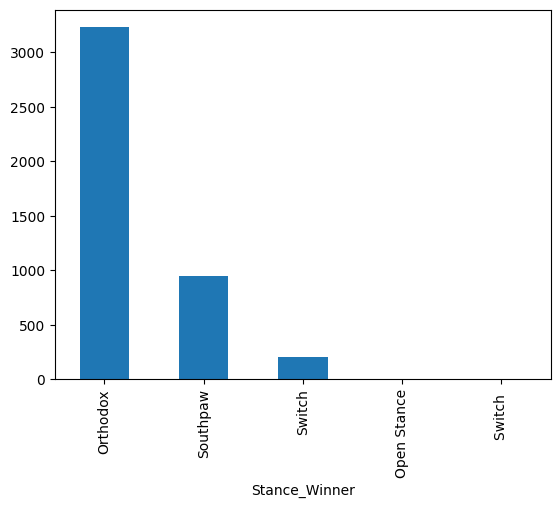

In [ ]:
df['Stance_Winner'].value_counts().plot(kind = 'bar')

<Axes: xlabel='Stance_Loser'>

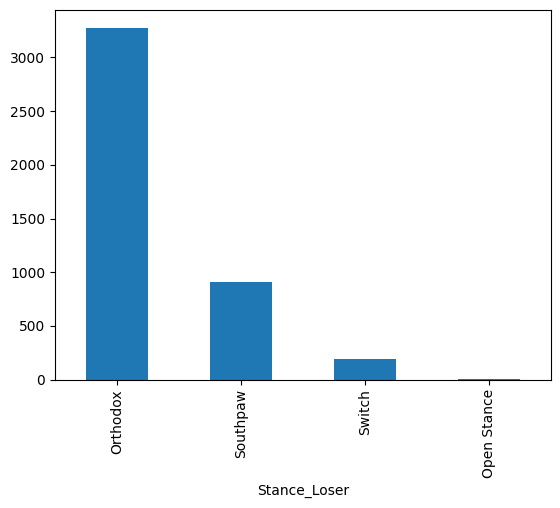

In [ ]:
df['Stance_Loser'].value_counts().plot(kind = 'bar')

We can see that our data for stances seems to behave as expected. Orthodox stances (left hand jab, right hand power hand) are the most common in fighting, with southpaw (right hand jab, left hand power hand) being less common. furthermore, the plots for both winners and losers are very similar, indicating that orthodox stances are more common regardless of success.

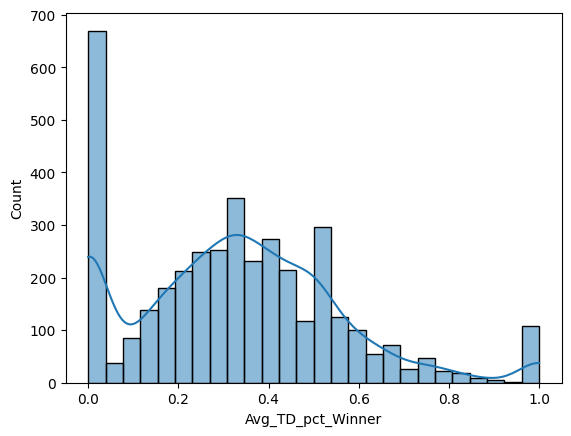

In [ ]:
import seaborn as sns
sns.histplot(data = df, x = 'Avg_TD_pct_Winner', kde = True);

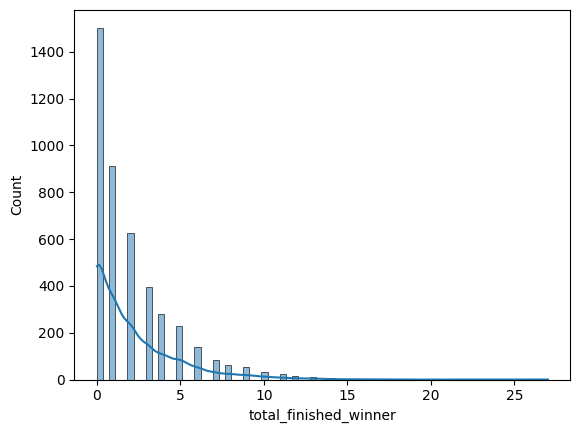

In [ ]:
sns.histplot(data = df, x = 'total_finished_winner', kde = True);

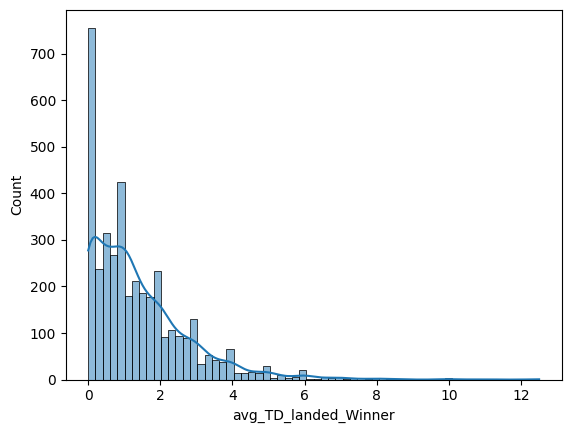

In [ ]:
sns.histplot(data = df, x = 'avg_TD_landed_Winner', kde = True);

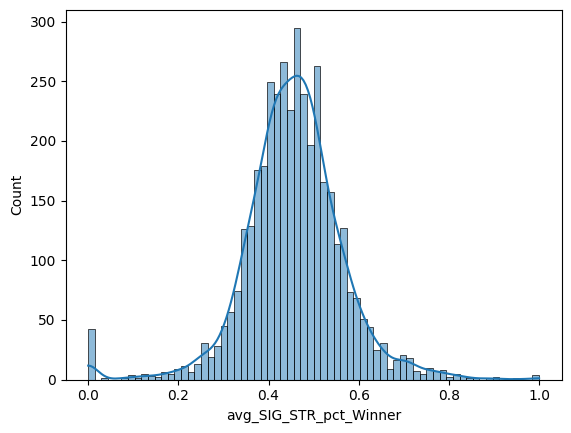

In [ ]:
sns.histplot(data = df, x = 'avg_SIG_STR_pct_Winner', kde = True);

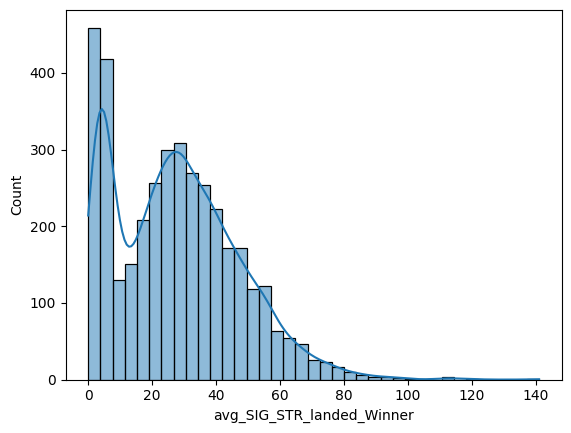

In [ ]:
sns.histplot(data = df, x = 'avg_SIG_STR_landed_Winner', kde = True);

### Differences

In [ ]:
nTDdf = df[df['avg_TD_landed_Winner'] <= 1]

In [ ]:
goodTDdf = df[df['avg_TD_landed_Winner'] > 1]

In [ ]:
champ_fights = df[df['title_bout'] == True]

In [ ]:
non_champ_fights = df[df['title_bout'] == False]

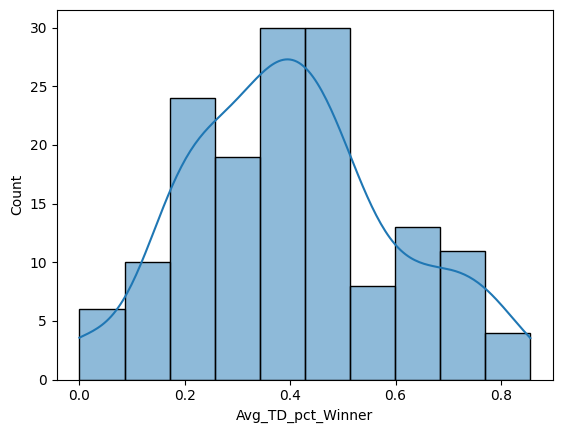

In [ ]:
sns.histplot(data = champ_fights, x = 'Avg_TD_pct_Winner', kde = True);

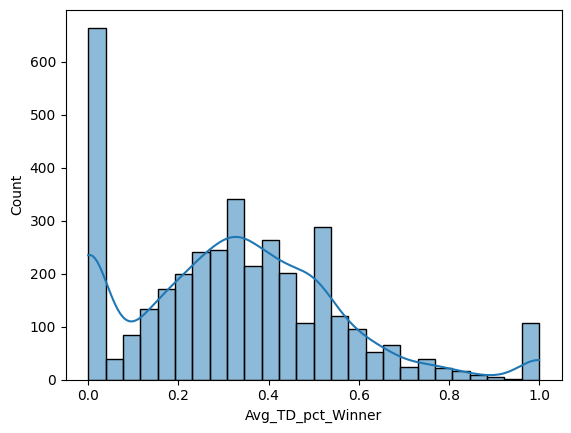

In [ ]:
sns.histplot(data = non_champ_fights, x = 'Avg_TD_pct_Winner', kde = True);

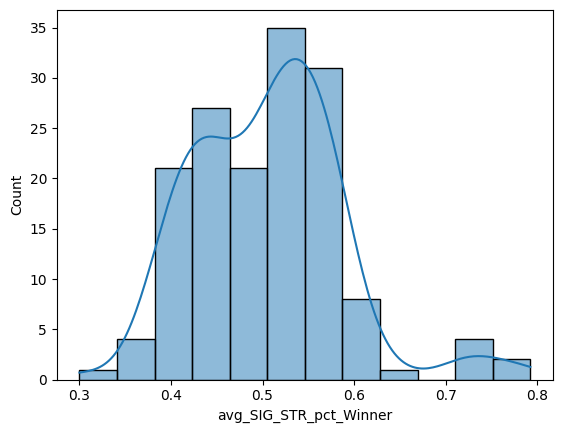

In [ ]:
sns.histplot(data = champ_fights, x = 'avg_SIG_STR_pct_Winner', kde = True);

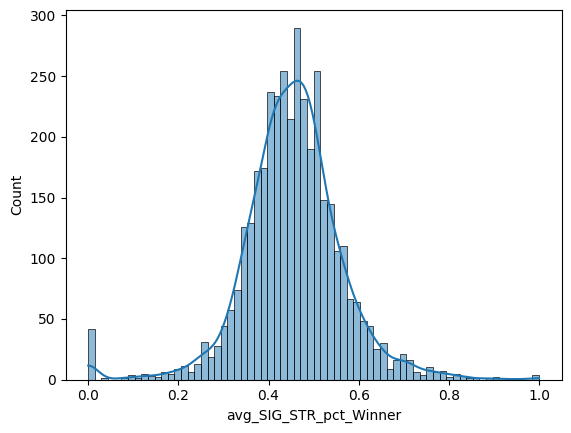

In [ ]:
sns.histplot(data = non_champ_fights, x = 'avg_SIG_STR_pct_Winner', kde = True);

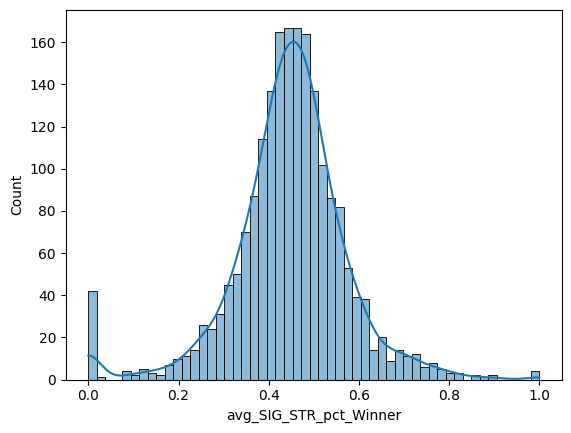

In [ ]:
sns.histplot(data = nTDdf, x = 'avg_SIG_STR_pct_Winner', kde = True);

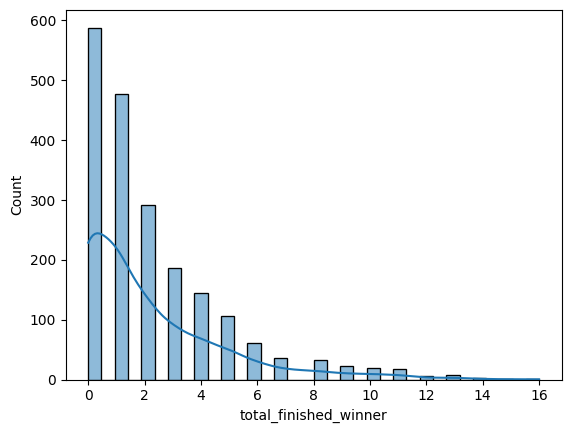

In [ ]:
sns.histplot(data = nTDdf, x = 'total_finished_winner', kde = True);

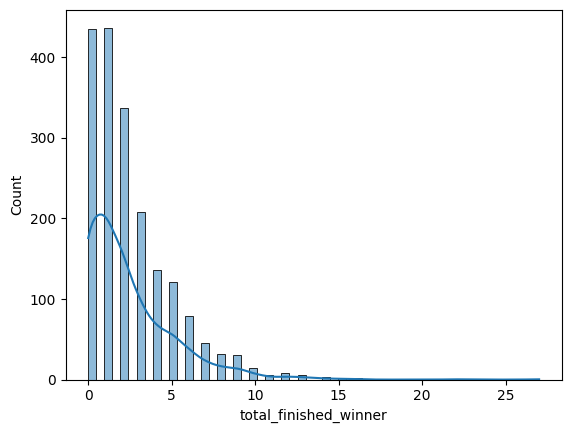

In [ ]:
sns.histplot(data = goodTDdf, x = 'total_finished_winner', kde = True);

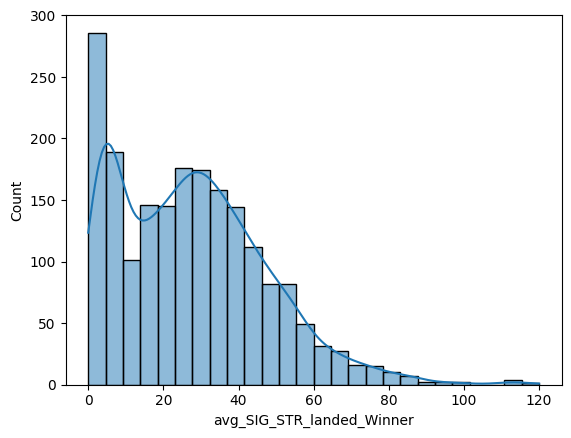

In [ ]:
sns.histplot(data = nTDdf, x = 'avg_SIG_STR_landed_Winner', kde = True);

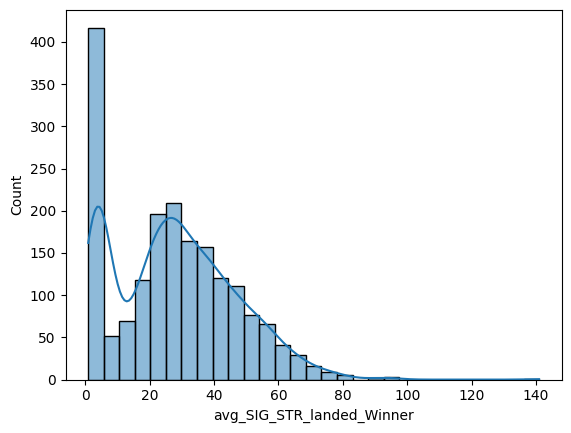

In [ ]:
sns.histplot(data = goodTDdf, x = 'avg_SIG_STR_landed_Winner', kde = True);

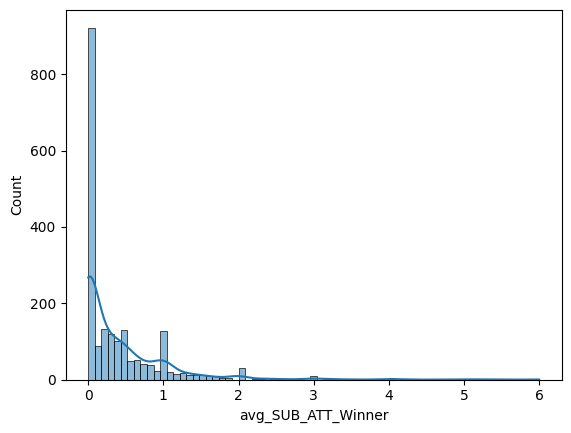

In [ ]:
sns.histplot(data = nTDdf, x = 'avg_SUB_ATT_Winner', kde = True);

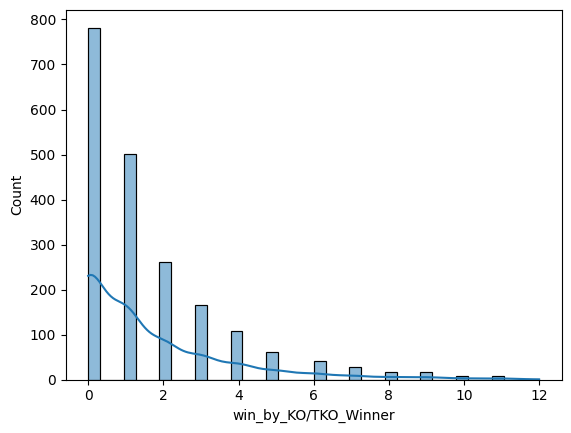

In [ ]:
sns.histplot(data = nTDdf, x = 'win_by_KO/TKO_Winner', kde = True);

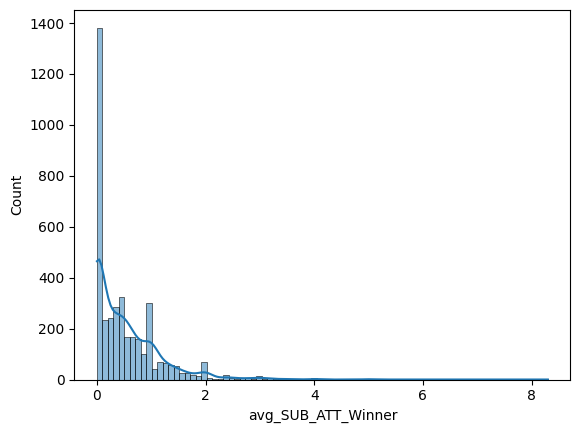

In [ ]:
sns.histplot(data = df, x = 'avg_SUB_ATT_Winner', kde = True);

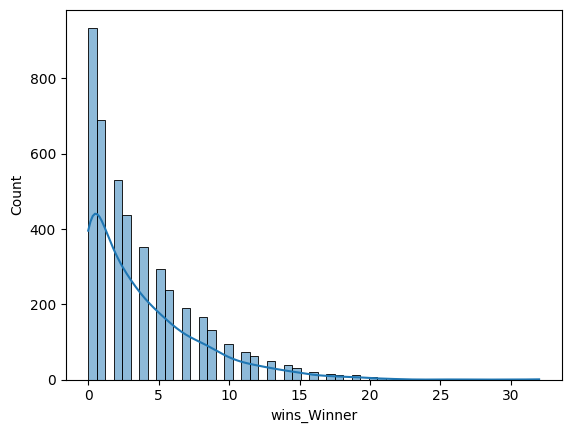

In [ ]:
sns.histplot(data = df, x = 'wins_Winner', kde = True);

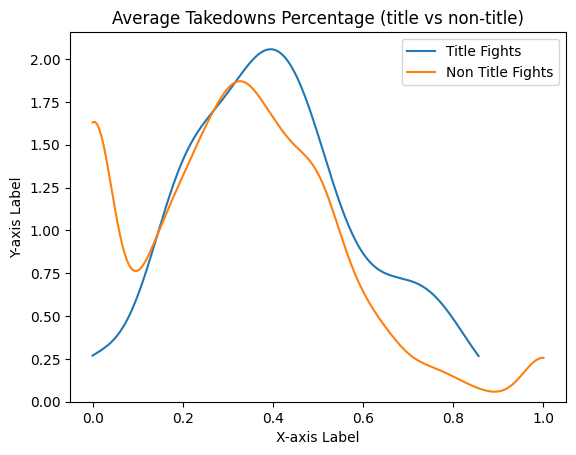

In [ ]:
import matplotlib.pyplot as plt
sns.kdeplot(data=champ_fights['Avg_TD_pct_Winner'], label='Title Fights', cut=0)
sns.kdeplot(data=non_champ_fights['Avg_TD_pct_Winner'], label='Non Title Fights', cut=0)

#sns.histplot(data = champ_fights, x = 'Avg_TD_pct_Winner', kde = True, label='Title Fights');
#sns.histplot(data = non_champ_fights, x = 'Avg_TD_pct_Winner', kde = True, label='Non Title Fights');
# Add more histograms as needed

# Set labels and title
plt.xlabel('X-axis Label')
plt.ylabel('Y-axis Label')
plt.title('Average Takedowns Percentage (title vs non-title)')
# Display legend
plt.legend()

# Show the plot
plt.show()

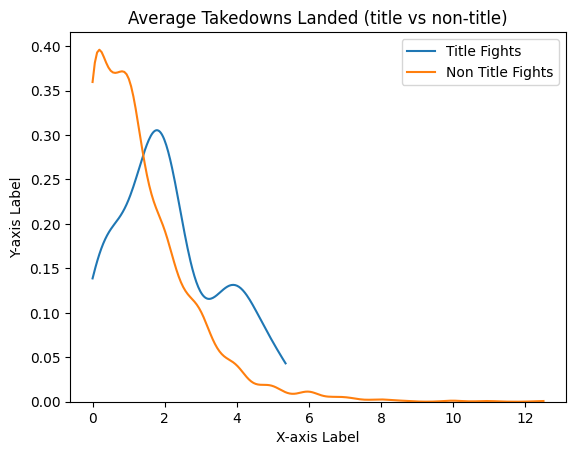

In [ ]:
import matplotlib.pyplot as plt
sns.kdeplot(data=champ_fights['avg_TD_landed_Winner'], label='Title Fights', cut=0)
sns.kdeplot(data=non_champ_fights['avg_TD_landed_Winner'], label='Non Title Fights', cut=0)

# Add more histograms as needed

# Set labels and title
plt.xlabel('X-axis Label')
plt.ylabel('Y-axis Label')
plt.title('Average Takedowns Landed (title vs non-title)')
# Display legend
plt.legend()

# Show the plot
plt.show()

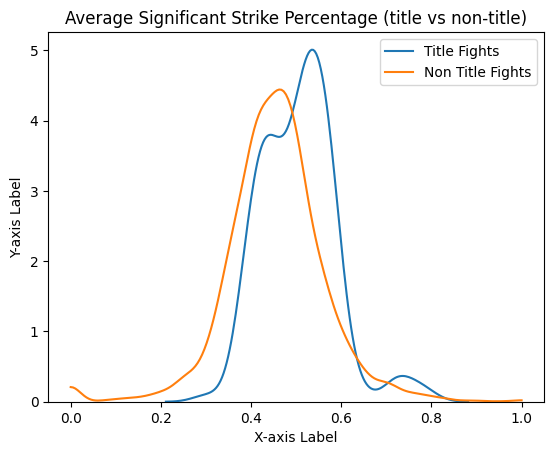

In [ ]:
sns.kdeplot(data=champ_fights['avg_SIG_STR_pct_Winner'], label='Title Fights')
sns.kdeplot(data=non_champ_fights['avg_SIG_STR_pct_Winner'], label='Non Title Fights', cut=0)

# Add more histograms as needed

# Set labels and title
plt.xlabel('X-axis Label')
plt.ylabel('Y-axis Label')
plt.title('Average Significant Strike Percentage (title vs non-title)')
# Display legend
plt.legend()

# Show the plot
plt.show()

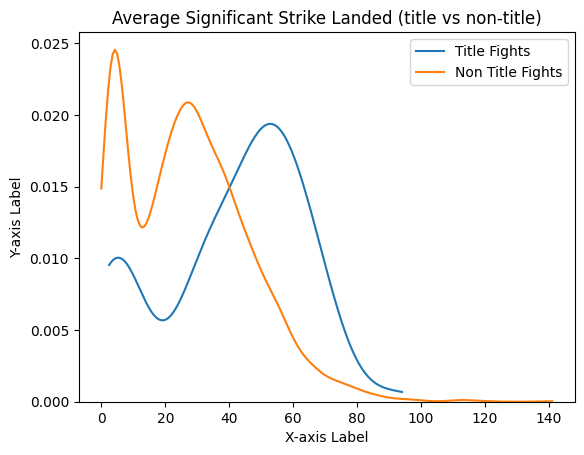

In [ ]:
sns.kdeplot(data=champ_fights['avg_SIG_STR_landed_Winner'], label='Title Fights', cut=0)
sns.kdeplot(data=non_champ_fights['avg_SIG_STR_landed_Winner'], label='Non Title Fights', cut=0)

# Add more histograms as needed

# Set labels and title
plt.xlabel('X-axis Label')
plt.ylabel('Y-axis Label')
plt.title('Average Significant Strike Landed (title vs non-title)')
# Display legend
plt.legend()

# Show the plot
plt.show()

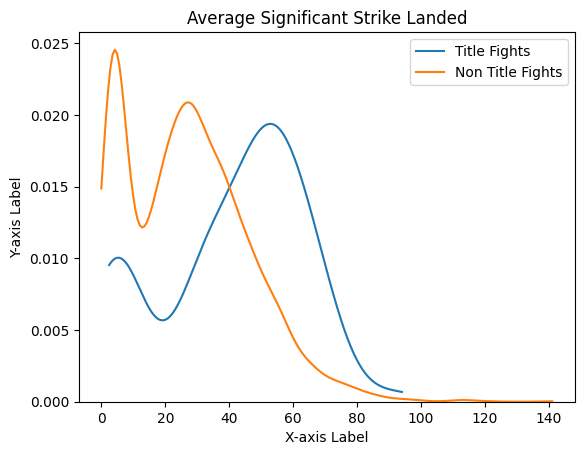

In [ ]:
sns.kdeplot(data=champ_fights['avg_SIG_STR_landed_Winner'], label='Title Fights', cut=0)
sns.kdeplot(data=non_champ_fights['avg_SIG_STR_landed_Winner'], label='Non Title Fights', cut=0)

# Add more histograms as needed

# Set labels and title
plt.xlabel('X-axis Label')
plt.ylabel('Y-axis Label')
plt.title('Average Significant Strike Landed')
# Display legend
plt.legend()

# Show the plot
plt.show()

In [ ]:

td_means = {
    'title_td_pct_mean': champ_fights['Avg_TD_pct_Winner'].mean(),
    'non_title_td_pct_mean': non_champ_fights['Avg_TD_pct_Winner'].mean(),
}
td_landed_means = {
    'title_td_pct_mean': champ_fights['avg_TD_landed_Winner'].mean(),
    'non_title_td_pct_mean': non_champ_fights['avg_TD_landed_Winner'].mean(),
}
sig_str_means = {
    'title_td_pct_mean': champ_fights['avg_SIG_STR_pct_Winner'].mean(),
    'non_title_td_pct_mean': non_champ_fights['avg_SIG_STR_pct_Winner'].mean(),
}
sig_str_landed_means = {
    'title_td_pct_mean': champ_fights['avg_SIG_STR_landed_Winner'].mean(),
    'non_title_td_pct_mean': non_champ_fights['avg_SIG_STR_landed_Winner'].mean(),
}

# Create DataFrames for means
mean_df = pd.DataFrame(list(td_means.items()), columns=['Title Status', 'td pct'])
mean_df['Title Status'] = mean_df['Title Status'].apply(lambda x: x.split('_')[0])

td_landed_df = pd.DataFrame(list(td_landed_means.items()), columns=['Title Status', 'td landed'])
td_landed_df['Title Status'] = td_landed_df['Title Status'].apply(lambda x: x.split('_')[0])

sig_str_df = pd.DataFrame(list(sig_str_means.items()), columns=['Title Status', 'sig str pct'])
sig_str_df['Title Status'] = sig_str_df['Title Status'].apply(lambda x: x.split('_')[0])

sig_str_landed_df = pd.DataFrame(list(sig_str_landed_means.items()), columns=['Title Status', 'sig str landed'])
sig_str_landed_df['Title Status'] = sig_str_landed_df['Title Status'].apply(lambda x: x.split('_')[0])

# Merge DataFrames on 'Weight Class'
result_df = pd.merge(mean_df, td_landed_df, on='Title Status')
result_df = pd.merge(result_df, sig_str_df, on='Title Status')
result_df = pd.merge(result_df, sig_str_landed_df, on='Title Status')
print("Mean Stats for Title vs non-Title Fights")
print(result_df)

Mean Stats for Title vs non-Title Fights
  Title Status    td pct  td landed  sig str pct  sig str landed
0        title  0.400862   2.094245     0.505095       40.891302
1          non  0.322772   1.375531     0.453375       26.973832


## 3-B: Weight Class Analysis


In [ ]:
heavy_df = df[df['weight_class'] == 'Heavyweight']

In [ ]:
df['weight_class'].unique()

array(['Light Heavyweight', 'Welterweight', 'Middleweight', 'Lightweight',
       'Bantamweight', 'Featherweight', 'Heavyweight', 'Catch Weight',
       'Flyweight'], dtype=object)

In [ ]:
lHeavy_df = df[df['weight_class'] == 'Light Heavyweight']
middle_df = df[df['weight_class'] == 'Middleweight']
welter_df = df[df['weight_class'] == 'Welterweight']
light_df = df[df['weight_class'] == 'Lightweight']
feather_df = df[df['weight_class'] == 'Featherweight']
bantam_df = df[df['weight_class'] == 'Bantamweight']
fly_df = df[df['weight_class'] == 'Flyweight']
td_means = {
    'heavy_td_pct_mean': heavy_df['Avg_TD_pct_Winner'].mean(),
    'lHeavy_td_pct_mean': lHeavy_df['Avg_TD_pct_Winner'].mean(),
    'middle_td_pct_mean': middle_df['Avg_TD_pct_Winner'].mean(),
    'welter_td_pct_mean': welter_df['Avg_TD_pct_Winner'].mean(),
    'light_td_pct_mean': light_df['Avg_TD_pct_Winner'].mean(),
    'feather_td_pct_mean': feather_df['Avg_TD_pct_Winner'].mean(),
    'bantam_td_pct_mean': bantam_df['Avg_TD_pct_Winner'].mean(),
    'fly_td_pct_mean': fly_df['Avg_TD_pct_Winner'].mean(),
}
td_landed_means = {
    'heavy_td_pct_mean': heavy_df['avg_TD_landed_Winner'].mean(),
    'lHeavy_td_pct_mean': lHeavy_df['avg_TD_landed_Winner'].mean(),
    'middle_td_pct_mean': middle_df['avg_TD_landed_Winner'].mean(),
    'welter_td_pct_mean': welter_df['avg_TD_landed_Winner'].mean(),
    'light_td_pct_mean': light_df['avg_TD_landed_Winner'].mean(),
    'feather_td_pct_mean': feather_df['avg_TD_landed_Winner'].mean(),
    'bantam_td_pct_mean': bantam_df['avg_TD_landed_Winner'].mean(),
    'fly_td_pct_mean': fly_df['avg_TD_landed_Winner'].mean(),
}
sig_str_means = {
    'heavy_td_pct_mean': heavy_df['avg_SIG_STR_pct_Winner'].mean(),
    'lHeavy_td_pct_mean': lHeavy_df['avg_SIG_STR_pct_Winner'].mean(),
    'middle_td_pct_mean': middle_df['avg_SIG_STR_pct_Winner'].mean(),
    'welter_td_pct_mean': welter_df['avg_SIG_STR_pct_Winner'].mean(),
    'light_td_pct_mean': light_df['avg_SIG_STR_pct_Winner'].mean(),
    'feather_td_pct_mean': feather_df['avg_SIG_STR_pct_Winner'].mean(),
    'bantam_td_pct_mean': bantam_df['avg_SIG_STR_pct_Winner'].mean(),
    'fly_td_pct_mean': fly_df['avg_SIG_STR_pct_Winner'].mean(),
}
sig_str_landed_means = {
    'heavy_td_pct_mean': heavy_df['avg_SIG_STR_landed_Winner'].mean(),
    'lHeavy_td_pct_mean': lHeavy_df['avg_SIG_STR_landed_Winner'].mean(),
    'middle_td_pct_mean': middle_df['avg_SIG_STR_landed_Winner'].mean(),
    'welter_td_pct_mean': welter_df['avg_SIG_STR_landed_Winner'].mean(),
    'light_td_pct_mean': light_df['avg_SIG_STR_landed_Winner'].mean(),
    'feather_td_pct_mean': feather_df['avg_SIG_STR_landed_Winner'].mean(),
    'bantam_td_pct_mean': bantam_df['avg_SIG_STR_landed_Winner'].mean(),
    'fly_td_pct_mean': fly_df['avg_SIG_STR_landed_Winner'].mean(),
}

# Create DataFrames for means
mean_df = pd.DataFrame(list(td_means.items()), columns=['Weight Class', 'td pct'])
mean_df['Weight Class'] = mean_df['Weight Class'].apply(lambda x: x.split('_')[0])

td_landed_df = pd.DataFrame(list(td_landed_means.items()), columns=['Weight Class', 'td landed'])
td_landed_df['Weight Class'] = td_landed_df['Weight Class'].apply(lambda x: x.split('_')[0])

sig_str_df = pd.DataFrame(list(sig_str_means.items()), columns=['Weight Class', 'sig str pct'])
sig_str_df['Weight Class'] = sig_str_df['Weight Class'].apply(lambda x: x.split('_')[0])

sig_str_landed_df = pd.DataFrame(list(sig_str_landed_means.items()), columns=['Weight Class', 'sig str landed'])
sig_str_landed_df['Weight Class'] = sig_str_landed_df['Weight Class'].apply(lambda x: x.split('_')[0])

# Merge DataFrames on 'Weight Class'
result_df = pd.merge(mean_df, td_landed_df, on='Weight Class')
result_df = pd.merge(result_df, sig_str_df, on='Weight Class')
result_df = pd.merge(result_df, sig_str_landed_df, on='Weight Class')

print("New DataFrame with takedown percentages, takedowns landed, sig str pct, and sig str landed:")
print(result_df)

New DataFrame with takedown percentages, takedowns landed, sig str pct, and sig str landed:
  Weight Class    td pct  td landed  sig str pct  sig str landed
0        heavy  0.282721   0.954355     0.494051       23.219927
1       lHeavy  0.308548   1.198478     0.484492       26.102878
2       middle  0.306187   1.343188     0.478507       25.189707
3       welter  0.342273   1.459086     0.461101       27.701419
4        light  0.335580   1.535067     0.434418       28.853881
5      feather  0.330248   1.389732     0.432716       29.765646
6       bantam  0.337061   1.539241     0.439590       29.113585
7          fly  0.337802   1.668577     0.425869       30.285261


### Takedown Percentage

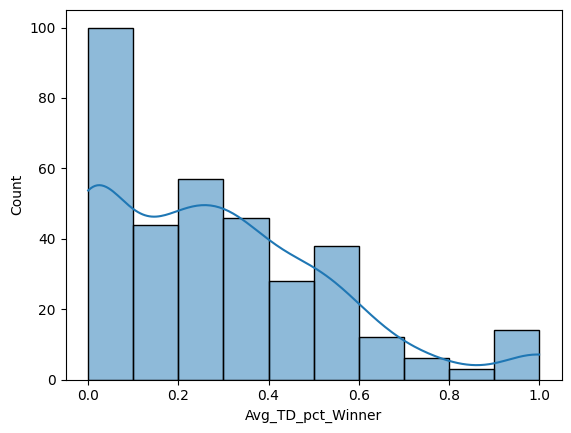

In [ ]:
sns.histplot(data = heavy_df, x = 'Avg_TD_pct_Winner', kde = True);

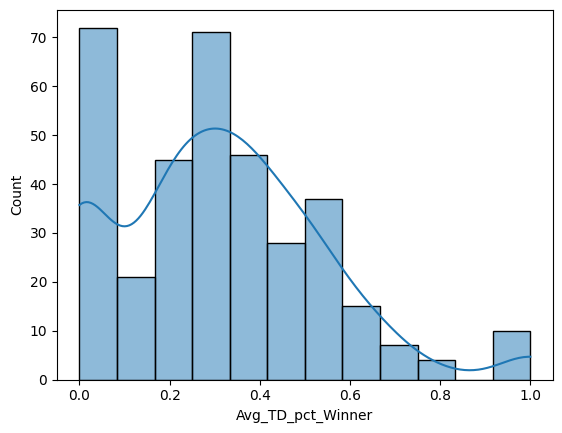

In [ ]:
sns.histplot(data = lHeavy_df, x = 'Avg_TD_pct_Winner', kde = True);

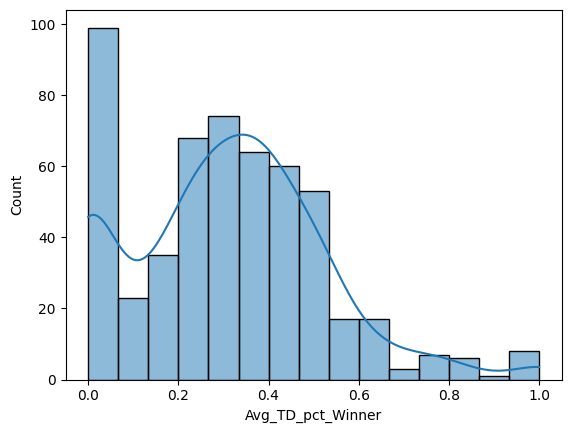

In [ ]:
sns.histplot(data = middle_df, x = 'Avg_TD_pct_Winner', kde = True);

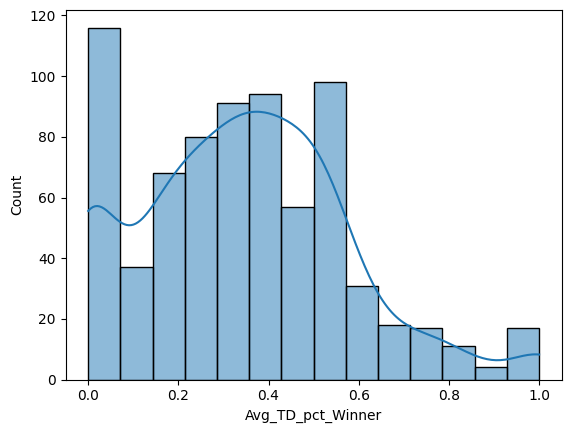

In [ ]:
sns.histplot(data = welter_df, x = 'Avg_TD_pct_Winner', kde = True);

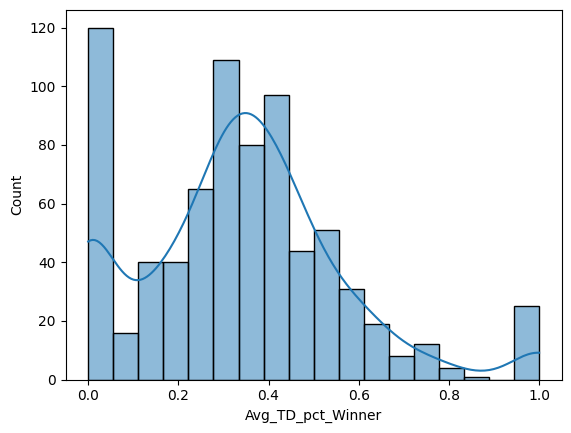

In [ ]:
sns.histplot(data = light_df, x = 'Avg_TD_pct_Winner', kde = True);

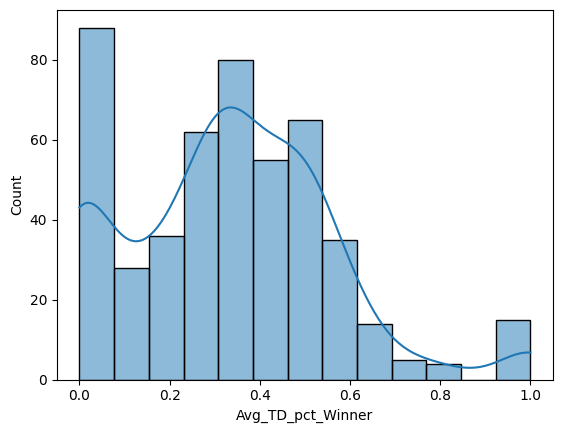

In [ ]:
sns.histplot(data = feather_df, x = 'Avg_TD_pct_Winner', kde = True);

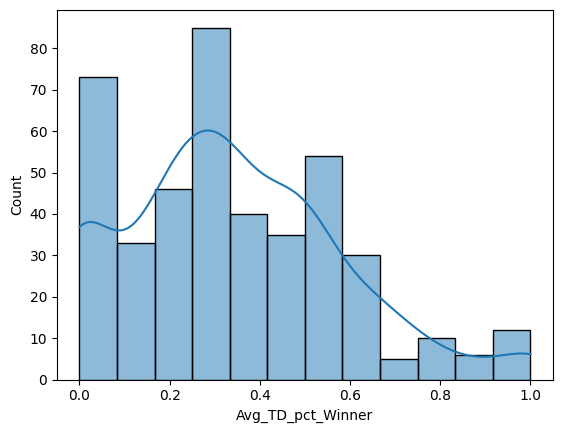

In [ ]:
sns.histplot(data = bantam_df, x = 'Avg_TD_pct_Winner', kde = True);

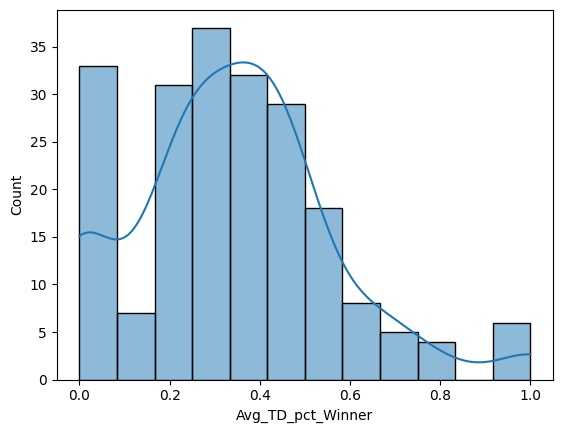

In [ ]:
sns.histplot(data = fly_df, x = 'Avg_TD_pct_Winner', kde = True);

### Takedowns Landed

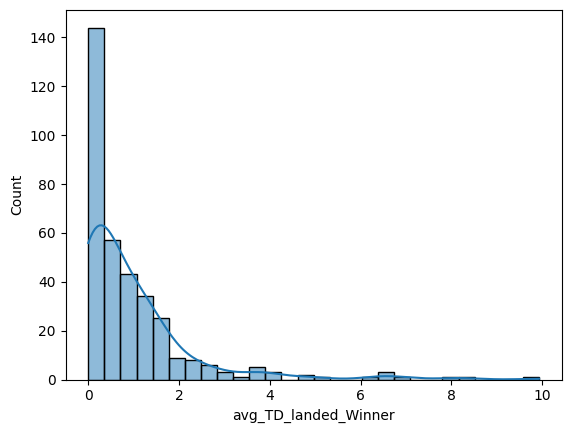

In [ ]:
sns.histplot(data = heavy_df, x = 'avg_TD_landed_Winner', kde = True);

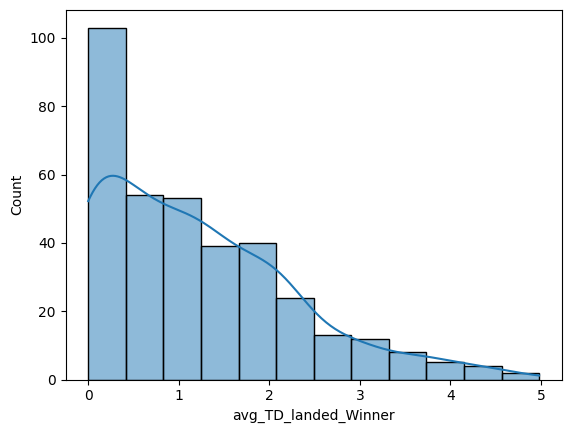

In [ ]:
sns.histplot(data = lHeavy_df, x = 'avg_TD_landed_Winner', kde = True);

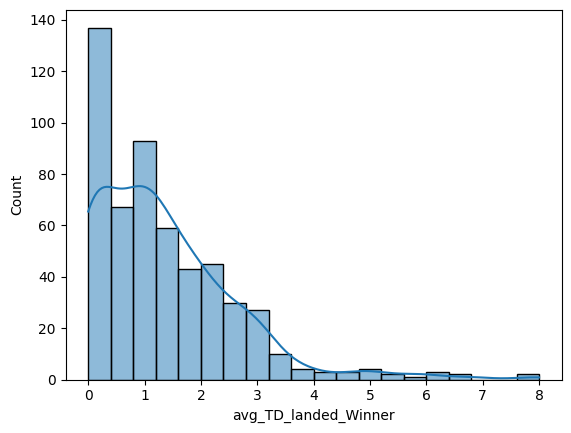

In [ ]:
sns.histplot(data = middle_df, x = 'avg_TD_landed_Winner', kde = True);

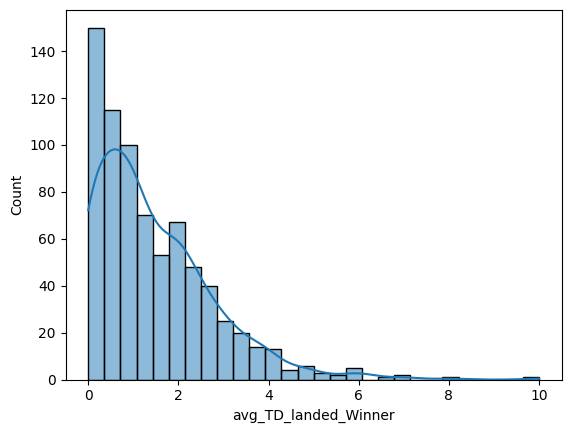

In [ ]:
sns.histplot(data = welter_df, x = 'avg_TD_landed_Winner', kde = True);

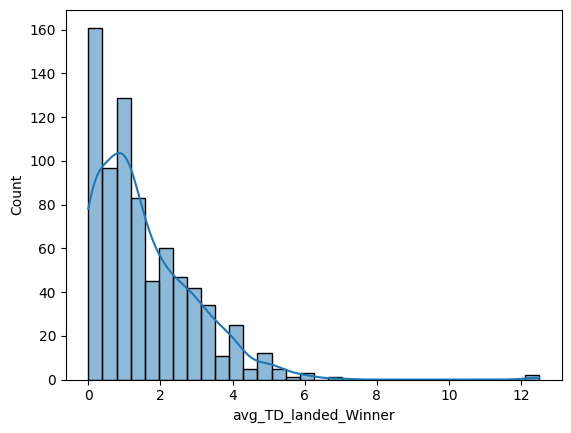

In [ ]:
sns.histplot(data = light_df, x = 'avg_TD_landed_Winner', kde = True);

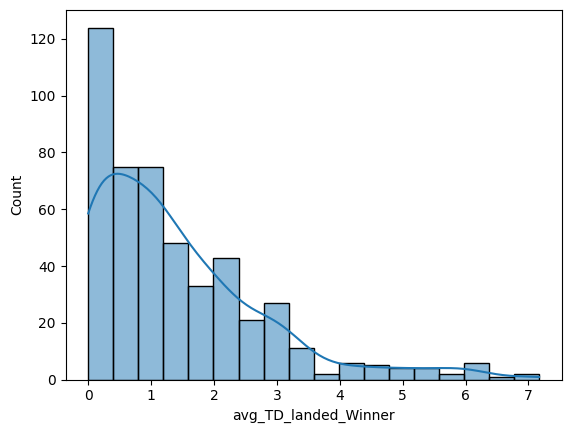

In [ ]:
sns.histplot(data = feather_df, x = 'avg_TD_landed_Winner', kde = True);

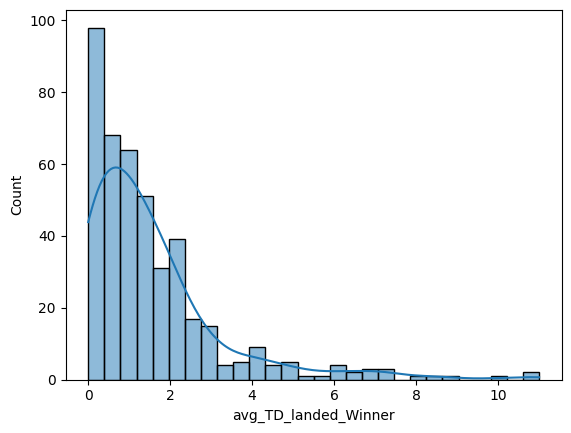

In [ ]:
sns.histplot(data = bantam_df, x = 'avg_TD_landed_Winner', kde = True);

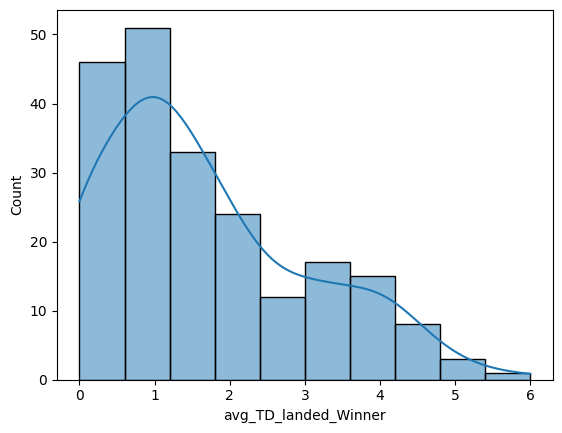

In [ ]:
sns.histplot(data = fly_df, x = 'avg_TD_landed_Winner', kde = True);

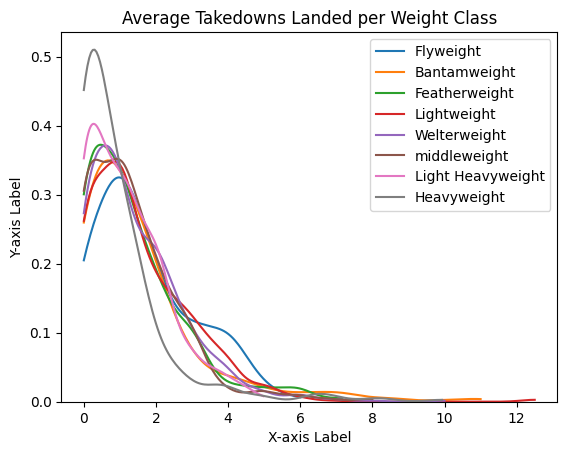

In [ ]:
import matplotlib.pyplot as plt
sns.kdeplot(data=fly_df['avg_TD_landed_Winner'], label='Flyweight', cut=0)
sns.kdeplot(data=bantam_df['avg_TD_landed_Winner'], label='Bantamweight', cut=0)
sns.kdeplot(data=feather_df['avg_TD_landed_Winner'], label='Featherweight', cut=0)
sns.kdeplot(data=light_df['avg_TD_landed_Winner'], label='Lightweight', cut=0)
sns.kdeplot(data=welter_df['avg_TD_landed_Winner'], label='Welterweight', cut=0)
sns.kdeplot(data=middle_df['avg_TD_landed_Winner'], label='middleweight', cut=0)
sns.kdeplot(data=lHeavy_df['avg_TD_landed_Winner'], label='Light Heavyweight', cut=0)
sns.kdeplot(data=heavy_df['avg_TD_landed_Winner'], label='Heavyweight', cut=0)

# Add more histograms as needed

# Set labels and title
plt.xlabel('X-axis Label')
plt.ylabel('Y-axis Label')
plt.title('Average Takedowns Landed per Weight Class')
# Display legend
plt.legend()

# Show the plot
plt.show()

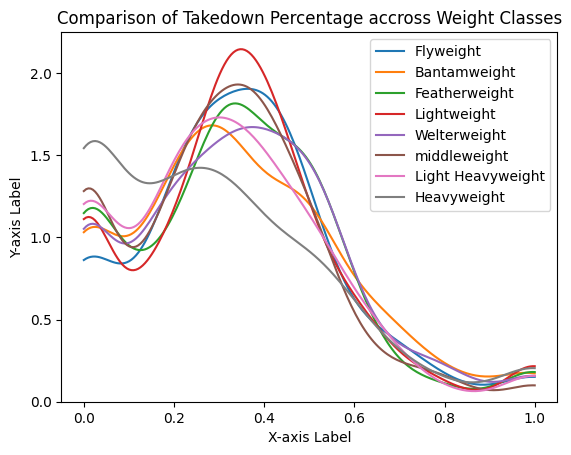

In [ ]:
sns.kdeplot(data=fly_df['Avg_TD_pct_Winner'], label='Flyweight', cut=0)
sns.kdeplot(data=bantam_df['Avg_TD_pct_Winner'], label='Bantamweight', cut=0)
sns.kdeplot(data=feather_df['Avg_TD_pct_Winner'], label='Featherweight', cut=0)
sns.kdeplot(data=light_df['Avg_TD_pct_Winner'], label='Lightweight', cut=0)
sns.kdeplot(data=welter_df['Avg_TD_pct_Winner'], label='Welterweight', cut=0)
sns.kdeplot(data=middle_df['Avg_TD_pct_Winner'], label='middleweight', cut=0)
sns.kdeplot(data=lHeavy_df['Avg_TD_pct_Winner'], label='Light Heavyweight', cut=0)
sns.kdeplot(data=heavy_df['Avg_TD_pct_Winner'], label='Heavyweight', cut=0)

# Add more histograms as needed

# Set labels and title
plt.xlabel('X-axis Label')
plt.ylabel('Y-axis Label')
plt.title('Comparison of Takedown Percentage accross Weight Classes')

# Display legend
plt.legend()

# Show the plot
plt.show()

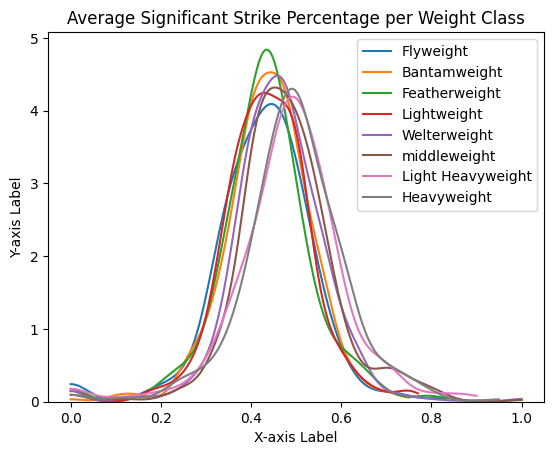

In [ ]:
sns.kdeplot(data=fly_df['avg_SIG_STR_pct_Winner'], label='Flyweight', cut=0)
sns.kdeplot(data=bantam_df['avg_SIG_STR_pct_Winner'], label='Bantamweight', cut=0)
sns.kdeplot(data=feather_df['avg_SIG_STR_pct_Winner'], label='Featherweight', cut=0)
sns.kdeplot(data=light_df['avg_SIG_STR_pct_Winner'], label='Lightweight', cut=0)
sns.kdeplot(data=welter_df['avg_SIG_STR_pct_Winner'], label='Welterweight', cut=0)
sns.kdeplot(data=middle_df['avg_SIG_STR_pct_Winner'], label='middleweight', cut=0)
sns.kdeplot(data=lHeavy_df['avg_SIG_STR_pct_Winner'], label='Light Heavyweight', cut=0)
sns.kdeplot(data=heavy_df['avg_SIG_STR_pct_Winner'], label='Heavyweight', cut=0)

# Add more histograms as needed

# Set labels and title
plt.xlabel('X-axis Label')
plt.ylabel('Y-axis Label')
plt.title('Average Significant Strike Percentage per Weight Class')

# Display legend
plt.legend()

# Show the plot
plt.show()

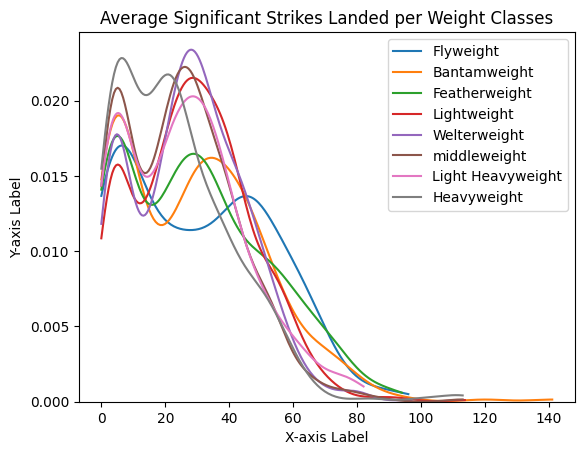

In [ ]:
sns.kdeplot(data=fly_df['avg_SIG_STR_landed_Winner'], label='Flyweight', cut=0)
sns.kdeplot(data=bantam_df['avg_SIG_STR_landed_Winner'], label='Bantamweight', cut=0)
sns.kdeplot(data=feather_df['avg_SIG_STR_landed_Winner'], label='Featherweight', cut=0)
sns.kdeplot(data=light_df['avg_SIG_STR_landed_Winner'], label='Lightweight', cut=0)
sns.kdeplot(data=welter_df['avg_SIG_STR_landed_Winner'], label='Welterweight', cut=0)
sns.kdeplot(data=middle_df['avg_SIG_STR_landed_Winner'], label='middleweight', cut=0)
sns.kdeplot(data=lHeavy_df['avg_SIG_STR_landed_Winner'], label='Light Heavyweight', cut=0)
sns.kdeplot(data=heavy_df['avg_SIG_STR_landed_Winner'], label='Heavyweight', cut=0)

# Add more histograms as needed

# Set labels and title
plt.xlabel('X-axis Label')
plt.ylabel('Y-axis Label')
plt.title('Average Significant Strikes Landed per Weight Classes')

# Display legend
plt.legend()

# Show the plot
plt.show()

### Significant Strike Percentage


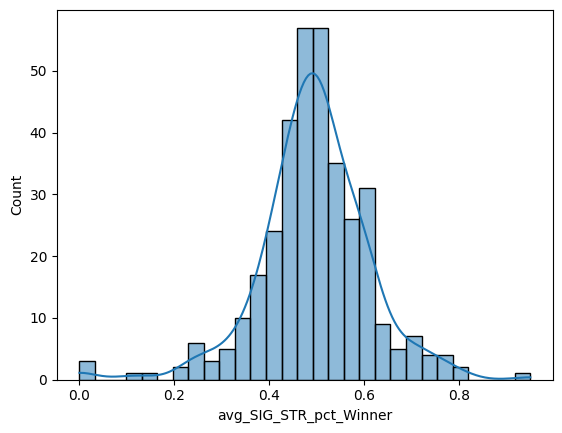

In [ ]:
sns.histplot(data = heavy_df, x = 'avg_SIG_STR_pct_Winner', kde = True);

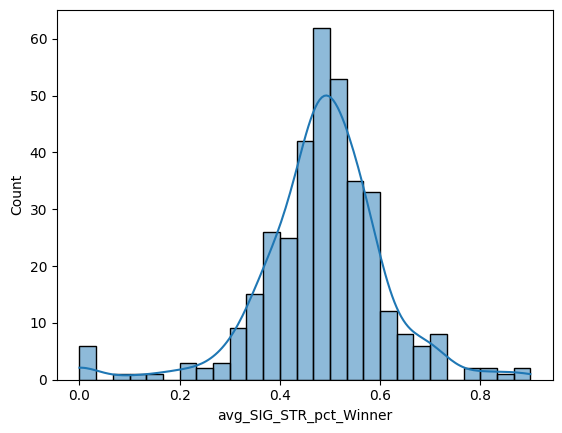

In [ ]:
sns.histplot(data = lHeavy_df, x = 'avg_SIG_STR_pct_Winner', kde = True);

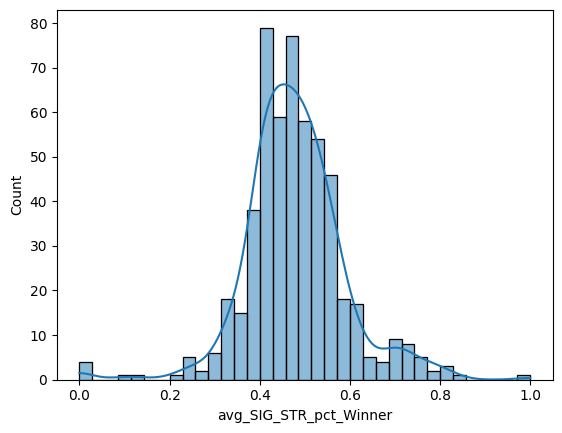

In [ ]:
sns.histplot(data = middle_df, x = 'avg_SIG_STR_pct_Winner', kde = True);

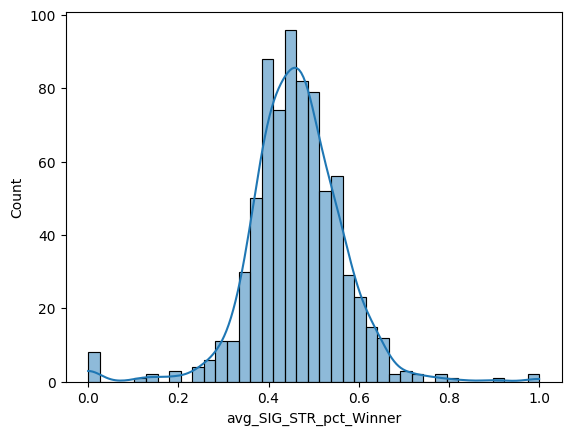

In [ ]:
sns.histplot(data = welter_df, x = 'avg_SIG_STR_pct_Winner', kde = True);

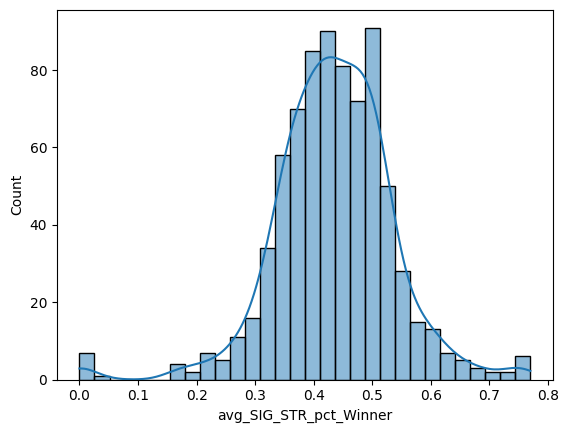

In [ ]:
sns.histplot(data = light_df, x = 'avg_SIG_STR_pct_Winner', kde = True);

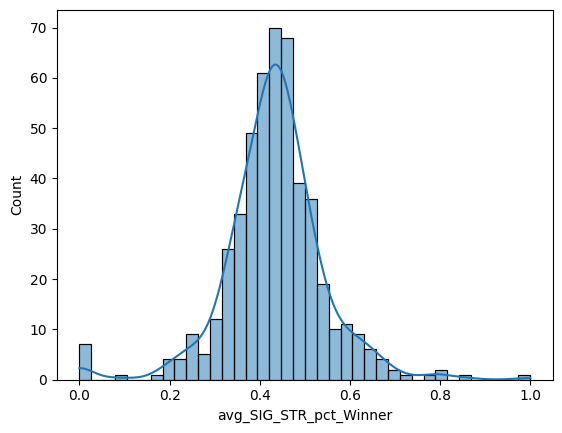

In [ ]:
sns.histplot(data = feather_df, x = 'avg_SIG_STR_pct_Winner', kde = True);

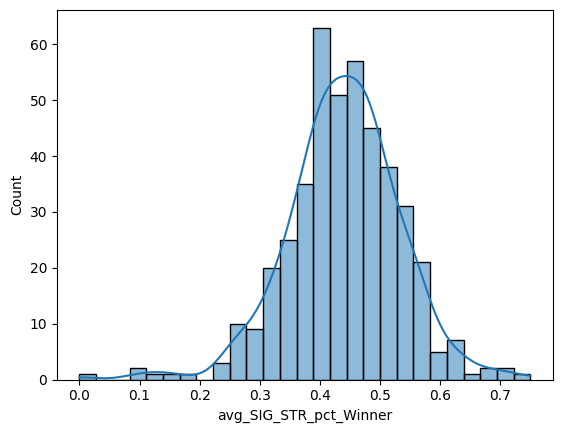

In [ ]:
sns.histplot(data = bantam_df, x = 'avg_SIG_STR_pct_Winner', kde = True);

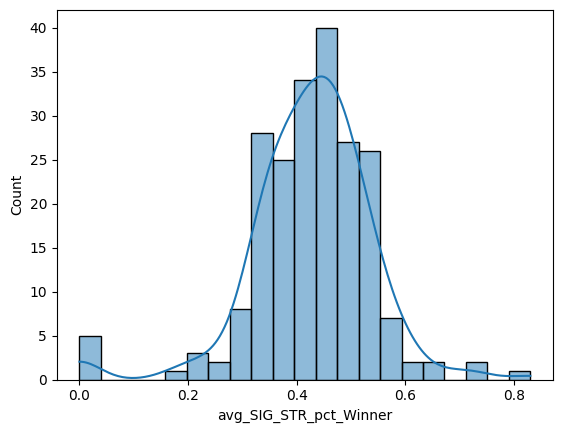

In [ ]:
sns.histplot(data = fly_df, x = 'avg_SIG_STR_pct_Winner', kde = True);

Text(0, 0.5, 'avg_TD_landed_Winner')

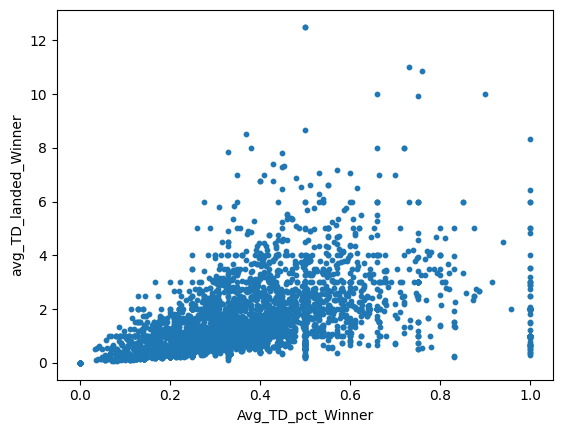

In [ ]:
import matplotlib.pyplot as plt
plt.scatter(df['Avg_TD_pct_Winner'], df['avg_TD_landed_Winner'], s=10)
plt.xlabel('Avg_TD_pct_Winner')
plt.ylabel('avg_TD_landed_Winner')


Text(0, 0.5, 'avg_SIG_STR_landed_Winner')

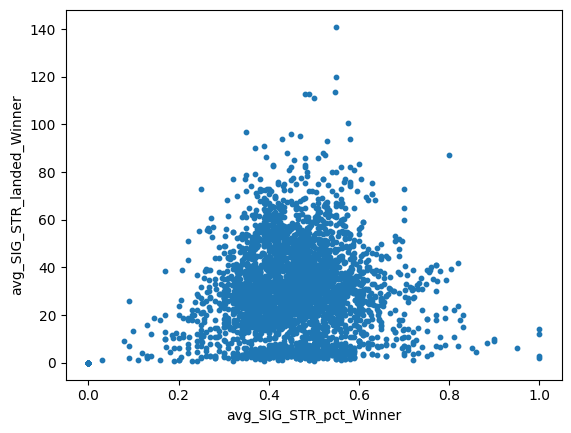

In [ ]:
plt.scatter(df['avg_SIG_STR_pct_Winner'], df['avg_SIG_STR_landed_Winner'], s=10)
plt.xlabel('avg_SIG_STR_pct_Winner')
plt.ylabel('avg_SIG_STR_landed_Winner')

# Part IV: Prediction and Inference

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import precision_score, recall_score
from sklearn.model_selection import cross_val_score
from sklearn import preprocessing
from sklearn.metrics import f1_score
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score
import sys, warnings, os
from sklearn.dummy import DummyClassifier
from sklearn.preprocessing import MinMaxScaler

### Loading in the Data

In [ ]:
#This function lets us see all results
pd.set_option("display.max_columns", None, "display.max_rows", None)

In [ ]:
#Loading in the dataset
df = pd.read_csv("ufc-master.csv")

In [ ]:
label = df.Winner
X = df.drop(['Winner',"B_Women's Featherweight_rank"], axis =1)

### imputing data, testing the accuracy on a Dummy Classifier

In [ ]:
#Separating the features based on their data types
cat_col = [col for col in X.columns if X[col].dtypes == 'object']
num_col = [col for col in X.columns if col not in cat_col]

In [ ]:
enc = LabelEncoder()
for i in X[cat_col]:
    #using astype(str) to avoid columns with 'float and str' to throw errors
    X[i] = enc.fit_transform(X[i].astype(str))

In [ ]:
#Also encoding Label for Red to be 1 and Blue to be 0
label = [1 if win == 'Red' else 0 for win in label]

In [ ]:
X_train, X_valid, y_train, y_valid = train_test_split(X, label, random_state = 2, test_size = 0.3)

In [ ]:
#can see the amount of null values in each column
X_train.isnull().sum().sort_values(ascending=False)

R_Women's Featherweight_rank    3424
B_Pound-for-Pound_rank          3401
B_Women's Flyweight_rank        3392
B_Women's Strawweight_rank      3385
R_Women's Flyweight_rank        3383
B_Bantamweight_rank             3376
B_Women's Bantamweight_rank     3372
B_Lightweight_rank              3370
B_Light Heavyweight_rank        3365
B_Featherweight_rank            3363
B_Welterweight_rank             3361
B_Flyweight_rank                3357
R_Women's Strawweight_rank      3356
B_Middleweight_rank             3354
B_Heavyweight_rank              3349
R_Women's Bantamweight_rank     3343
R_Featherweight_rank            3336
R_Bantamweight_rank             3336
R_Lightweight_rank              3333
R_Middleweight_rank             3331
R_Heavyweight_rank              3331
R_Light Heavyweight_rank        3330
R_Flyweight_rank                3329
R_Welterweight_rank             3321
R_Pound-for-Pound_rank          3320
B_match_weightclass_rank        2818
R_match_weightclass_rank        2503
b

In [ ]:
#imputes the most frequent value into missing values.
imp = SimpleImputer(strategy='most_frequent')

#fits the imputer to the training data
imp.fit(X_train[num_col])
X_train[num_col] = imp.transform(X_train[num_col])
X_valid[num_col] = imp.transform(X_valid[num_col])

In [ ]:
#same strategy for the categorical data
cat_imp = SimpleImputer(strategy = 'most_frequent')
cat_imp.fit(X_train[cat_col])
X_train[cat_col] = cat_imp.transform(X_train[cat_col])
X_valid[cat_col] = cat_imp.transform(X_valid[cat_col])

In [ ]:
X_train.sample(10)

,R_fighter,B_fighter,R_odds,B_odds,R_ev,B_ev,date,location,country,title_bout,weight_class,gender,no_of_rounds,B_current_lose_streak,B_current_win_streak,B_draw,B_avg_SIG_STR_landed,B_avg_SIG_STR_pct,B_avg_SUB_ATT,B_avg_TD_landed,B_avg_TD_pct,B_longest_win_streak,B_losses,B_total_rounds_fought,B_total_title_bouts,B_win_by_Decision_Majority,B_win_by_Decision_Split,B_win_by_Decision_Unanimous,B_win_by_KO/TKO,B_win_by_Submission,B_win_by_TKO_Doctor_Stoppage,B_wins,B_Stance,B_Height_cms,B_Reach_cms,B_Weight_lbs,R_current_lose_streak,R_current_win_streak,R_draw,R_avg_SIG_STR_landed,R_avg_SIG_STR_pct,R_avg_SUB_ATT,R_avg_TD_landed,R_avg_TD_pct,R_longest_win_streak,R_losses,R_total_rounds_fought,R_total_title_bouts,R_win_by_Decision_Majority,R_win_by_Decision_Split,R_win_by_Decision_Unanimous,R_win_by_KO/TKO,R_win_by_Submission,R_win_by_TKO_Doctor_Stoppage,R_wins,R_Stance,R_Height_cms,R_Reach_cms,R_Weight_lbs,R_age,B_age,lose_streak_dif,win_streak_dif,longest_win_streak_dif,win_dif,loss_dif,total_round_dif,total_title_bout_dif,ko_dif,sub_dif,height_dif,reach_dif,age_dif,sig_str_dif,avg_sub_att_dif,avg_td_dif,empty_arena,constant_1,B_match_weightclass_rank,R_match_weightclass_rank,R_Women's Flyweight_rank,R_Women's Featherweight_rank,R_Women's Strawweight_rank,R_Women's Bantamweight_rank,R_Heavyweight_rank,R_Light Heavyweight_rank,R_Middleweight_rank,R_Welterweight_rank,R_Lightweight_rank,R_Featherweight_rank,R_Bantamweight_rank,R_Flyweight_rank,R_Pound-for-Pound_rank,B_Women's Flyweight_rank,B_Women's Strawweight_rank,B_Women's Bantamweight_rank,B_Heavyweight_rank,B_Light Heavyweight_rank,B_Middleweight_rank,B_Welterweight_rank,B_Lightweight_rank,B_Featherweight_rank,B_Bantamweight_rank,B_Flyweight_rank,B_Pound-for-Pound_rank,better_rank,finish,finish_details,finish_round,finish_round_time,total_fight_time_secs,r_dec_odds,b_dec_odds,r_sub_odds,b_sub_odds,r_ko_odds,b_ko_odds
2587,776,410,-270.0,230.0,37.037037,230.000000,272,111,13,0.0,8,1,3.0,2.0,0.0,0.0,6.500000,0.120000,0.000000,2.500000,0.500000,0.0,2.0,4.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,185.42,200.66,170.0,1.0,0.0,0.0,24.500000,0.622500,0.000000,0.000000,0.000000,2.0,2.0,10.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,2.0,2,182.88,187.96,170.0,24.0,27.0,-1.0,0.0,-2.0,-2.0,0.0,-6.0,0.0,-1.0,0.0,2.54,12.70,-3.0,-18.000000,0.000000,2.500000,0.0,1.0,12.0,0.0,2.0,0.0,5.0,0.0,8.0,6.0,0.0,3.0,10.0,10.0,8.0,3.0,4.0,6.0,9.0,15.0,9.0,6.0,10.0,12.0,1.0,7.0,9.0,12.0,4.0,2,6,31,3.0,292,900.0,187.0,450.0,754.0,985.0,175.0,520.0
2671,648,1135,-260.0,220.0,38.461538,220.000000,152,101,21,0.0,8,1,3.0,1.0,0.0,0.0,11.000000,0.400000,0.000000,1.000000,1.000000,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2,177.80,175.26,170.0,1.0,0.0,0.0,23.000000,0.340000,2.000000,2.000000,0.250000,0.0,1.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,177.80,180.34,170.0,26.0,37.0,0.0,0.0,0.0,0.0,0.0,-2.0,0.0,0.0,0.0,0.00,-5.08,-11.0,-12.000000,-2.000000,-1.000000,0.0,1.0,12.0,0.0,2.0,0.0,5.0,0.0,8.0,6.0,0.0,3.0,10.0,10.0,8.0,3.0,4.0,6.0,9.0,15.0,9.0,6.0,10.0,12.0,1.0,7.0,9.0,12.0,4.0,2,6,31,3.0,292,900.0,245.0,343.0,244.0,1650.0,240.0,1010.0
2004,341,369,-210.0,175.0,47.619048,175.000000,334,138,21,0.0,2,1,3.0,0.0,4.0,0.0,34.937500,0.323750,1.125000,2.125000,0.352500,5.0,4.0,40.0,0.0,0.0,1.0,8.0,3.0,0.0,0.0,12.0,1,177.80,180.34,145.0,1.0,0.0,0.0,45.615385,0.457692,0.923077,2.923077,0.427692,7.0,4.0,30.0,1.0,0.0,2.0,4.0,1.0,2.0,0.0,9.0,1,167.64,167.64,155.0,30.0,33.0,1.0,4.0,-2.0,3.0,0.0,10.0,-1.0,2.0,-2.0,10.16,12.70,-3.0,-10.677885,0.201923,-0.798077,0.0,1.0,12.0,10.0,2.0,0.0,5.0,0.0,8.0,6.0,0.0,3.0,10.0,10.0,8.0,3.0,4.0,6.0,9.0,15.0,9.0,6.0,10.0,12.0,1.0,12.0,9.0,12.0,4.0,1,4,31,3.0,292,900.0,-120.0,375.0,950.0,900.0,525.0,575.0
4427,1191,883,138.0,-148.0,138.000000,67.567568,72,119,21,0.0,5,1,3.0,0.0,4.0,0.0,43.600000,0.448000,0.000000,3.200000,0.274000,4.0,1.0,13.0,0.0,0.0,1.0,2.0,1.0,0.0,0.0,4.0,1,193.04,193.04,205.0,0.0,2.0,0.0,31.615385,0.408462,0.923077,1.000000,0.210769,3.0,6.0,33.0,1.0,0.0,0.0,3.0,2.0,2.0,0.0,7.0,1,193.04,198

In [ ]:
base_model = DummyClassifier(random_state=2)

In [ ]:
base_model.fit(X_train,y_train)

DummyClassifier(random_state=2)

In [ ]:
preds = base_model.predict(X_valid)
accuracy_score(y_valid, preds)

0.5867937372362151

In [ ]:
df.head()

,R_fighter,B_fighter,R_odds,B_odds,R_ev,B_ev,date,location,country,Winner,title_bout,weight_class,gender,no_of_rounds,B_current_lose_streak,B_current_win_streak,B_draw,B_avg_SIG_STR_landed,B_avg_SIG_STR_pct,B_avg_SUB_ATT,B_avg_TD_landed,B_avg_TD_pct,B_longest_win_streak,B_losses,B_total_rounds_fought,B_total_title_bouts,B_win_by_Decision_Majority,B_win_by_Decision_Split,B_win_by_Decision_Unanimous,B_win_by_KO/TKO,B_win_by_Submission,B_win_by_TKO_Doctor_Stoppage,B_wins,B_Stance,B_Height_cms,B_Reach_cms,B_Weight_lbs,R_current_lose_streak,R_current_win_streak,R_draw,R_avg_SIG_STR_landed,R_avg_SIG_STR_pct,R_avg_SUB_ATT,R_avg_TD_landed,R_avg_TD_pct,R_longest_win_streak,R_losses,R_total_rounds_fought,R_total_title_bouts,R_win_by_Decision_Majority,R_win_by_Decision_Split,R_win_by_Decision_Unanimous,R_win_by_KO/TKO,R_win_by_Submission,R_win_by_TKO_Doctor_Stoppage,R_wins,R_Stance,R_Height_cms,R_Reach_cms,R_Weight_lbs,R_age,B_age,lose_streak_dif,win_streak_dif,longest_win_streak_dif,win_dif,loss_dif,total_round_dif,total_title_bout_dif,ko_dif,sub_dif,height_dif,reach_dif,age_dif,sig_str_dif,avg_sub_att_dif,avg_td_dif,empty_arena,constant_1,B_match_weightclass_rank,R_match_weightclass_rank,R_Women's Flyweight_rank,R_Women's Featherweight_rank,R_Women's Strawweight_rank,R_Women's Bantamweight_rank,R_Heavyweight_rank,R_Light Heavyweight_rank,R_Middleweight_rank,R_Welterweight_rank,R_Lightweight_rank,R_Featherweight_rank,R_Bantamweight_rank,R_Flyweight_rank,R_Pound-for-Pound_rank,B_Women's Flyweight_rank,B_Women's Featherweight_rank,B_Women's Strawweight_rank,B_Women's Bantamweight_rank,B_Heavyweight_rank,B_Light Heavyweight_rank,B_Middleweight_rank,B_Welterweight_rank,B_Lightweight_rank,B_Featherweight_rank,B_Bantamweight_rank,B_Flyweight_rank,B_Pound-for-Pound_rank,better_rank,finish,finish_details,finish_round,finish_round_time,total_fight_time_secs,r_dec_odds,b_dec_odds,r_sub_odds,b_sub_odds,r_ko_odds,b_ko_odds
0,Thiago Santos,Johnny Walker,-150.0,130,66.666667,130.000000,2021-10-02,"Las Vegas, Nevada, USA",USA,Red,False,Light Heavyweight,MALE,5,0,1,0,3.42,0.59,0.7,0.24,1.00,4,2,11,0,0,0,1,4,0,0,5,Orthodox,198.12,208.28,205,3,0,0,3.95,0.48,0.1,0.61,0.36,4,8,43,1,0,0,2,11,0,0,13,Orthodox,187.96,193.04,205,37,29,-3,1,0,-8,-6,-32,-1,-7,0,10.16,15.24,-8,-0.53,0.6,-0.37,1,1,10.0,5.0,NaN,NaN,NaN,NaN,NaN,5.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Red,U-DEC,NaN,5.0,5:00,1500.0,800.0,900.0,2000.0,1600.0,-110.0,175.0
1,Alex Oliveira,Niko Price,170.0,-200,170.000000,50.000000,2021-10-02,"Las Vegas, Nevada, USA",USA,Blue,False,Welterweight,MALE,3,2,0,0,5.16,0.42,0.8,0.79,0.22,2,5,24,0,0,0,0,4,2,0,6,Orthodox,182.88,193.04,170,2,0,0,2.97,0.51,0.5,2.27,0.37,4,8,44,0,0,1,3,4,3,0,11,Orthodox,180.34,193.04,170,33,32,0,0,-2,-5,-3,-20,0,0,-1,2.54,0.00,-1,2.19,0.3,-1.48,1,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,neither,U-DEC,NaN,3.0,5:00,900.0,450.0,350.0,700.0,1100.0,550.0,120.0
2,Misha Cirkunov,Krzysztof Jotko,110.0,-130,110.000000,76.923077,2021-10-02,"Las Vegas, Nevada, USA",USA,Blue,False,Middleweight,MALE,3,1,0,0,2.92,0.41,0.1,1.15,0.34,5,5,38,0,0,2,6,1,0,0,9,Southpaw,185.42,195.58,185,1,0,0,3.77,0.49,1.7,4.48,0.44,4,4,13,0,0,0,0,1,5,0,6,Orthodox,190.50,195.58,205,34,32,0,0,1,3,1,25,0,0,-5,-5.08,0.00,-2,-0.85,-1.6,-3.33,1,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,neither,S-DEC,NaN,3.0,5:00,900.0,550.0,275.0,275.0,1400.0,600.0,185.0
3,Alexander Hernandez,Mike Breeden,-675.0,475,14.814815,475.000000,2021-10-02,"Las Vegas, Nevada, USA",USA,Red,False,Lightweight,MALE,3,1,0,0,4.04,0.34,0.0,0.00,0.00,0,1,3,0,0,0,0,0,0,0,0,Orthodox,177.80,177.80,155,1,0,0,3.79,0.36,0.0,1.57,0.35,2,3,15,0,0,0,2,2,0,0,4,Orthodox,175.26,182.88,155,29,32,0,0,-2,-4,-2,-12,0,-2,0,2.54,-5.08,3,0.25,0.0,-1.57,1,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N

### Data Analysis, Preprocessing

In [ ]:
#Encoding label so it is easier to find correlation
df['Winner'] = [1 if winner == 'Red' else 0 for winner in df.Winner]

In [ ]:
df = df[df['gender'] == 'MALE']

In [ ]:
num_corr_col = [col for col in df.columns if df[col].dtype == 'int64' or df[col].dtype == 'float64']
corr_dict = {}
#Getting absolute values of correlation since we would need to inspect negative correlation too
for col in num_corr_col:
    corr_dict[col] = abs(df[col].corr(df['Winner']))

In [ ]:
for w in sorted(corr_dict, key=corr_dict.get):
    print(w, corr_dict[w])

B_win_by_Submission 0.000824570442406622
R_Height_cms 0.0016277680137514433
R_Weight_lbs 0.0026353948334274834
sub_dif 0.003303633437241906
empty_arena 0.004234791471225828
R_win_by_Submission 0.004562654796362771
B_avg_SUB_ATT 0.00575572494039087
R_draw 0.006175716063406249
R_win_by_Decision_Unanimous 0.007087453007788625
B_wins 0.008342720252229227
B_longest_win_streak 0.009771068517955839
total_title_bout_dif 0.010327174344073643
B_win_by_Decision_Majority 0.012541871279658036
B_win_by_TKO_Doctor_Stoppage 0.012783498641786172
B_avg_TD_pct 0.01318738309051308
R_Welterweight_rank 0.016217480197097452
B_total_rounds_fought 0.016769511767153706
B_win_by_KO/TKO 0.017394095523986627
B_current_lose_streak 0.017898284523374528
B_Weight_lbs 0.017940876872161084
R_win_by_Decision_Majority 0.017946281541790926
R_total_title_bouts 0.018176418518793917
R_Reach_cms 0.019920414547151315
B_Middleweight_rank 0.02011719647445769
R_wins 0.02064167683273762
B_avg_SIG_STR_pct 0.02078690383286776
B_win_b

In [ ]:
df['Winner'] = ['Red' if winner == 1 else 'Blue' for winner in df.Winner]

### visualizations

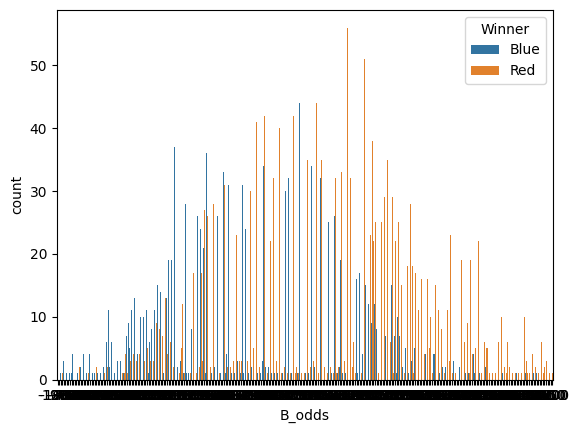

In [ ]:
#seeing how Odds compare with who wins
sns.countplot(x=df['B_odds'], hue = df['Winner']);

Text(0.5, 1.0, 'Scatter Plot of Red and Blue Odds')

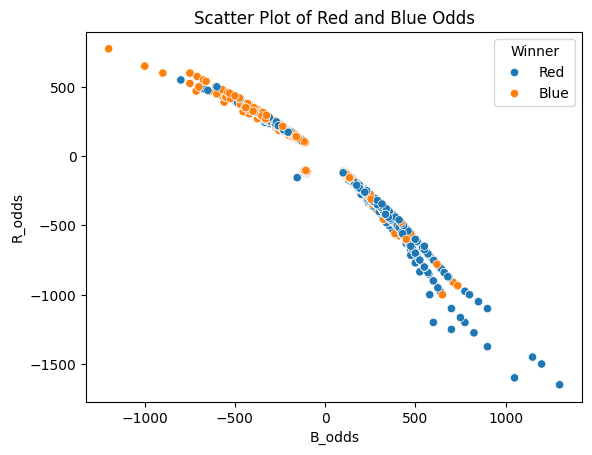

In [ ]:
sns.scatterplot(x="B_odds", y="R_odds", hue="Winner", data = df);
plt.title("Scatter Plot of Red and Blue Odds")

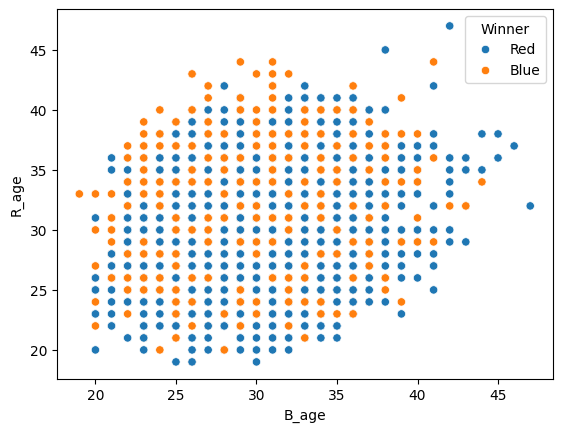

In [ ]:
sns.scatterplot(x="B_age", y="R_age", hue="Winner", data = df);

In [ ]:
#Just to be sure
df["Winner"].loc[df["B_odds"]>1].value_counts()

Winner
Red     1852
Blue     836
Name: count, dtype: int64

Text(0.5, 1.0, 'Scatter Plot of Red and Blue Ev')

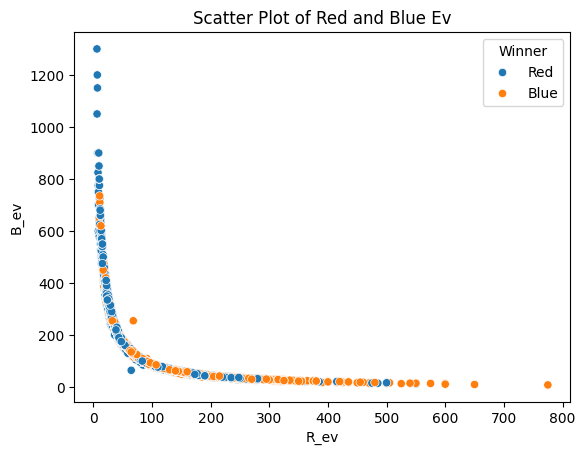

In [ ]:
sns.scatterplot(x='R_ev',y='B_ev',hue = 'Winner', data=df);
plt.title("Scatter Plot of Red and Blue Ev")

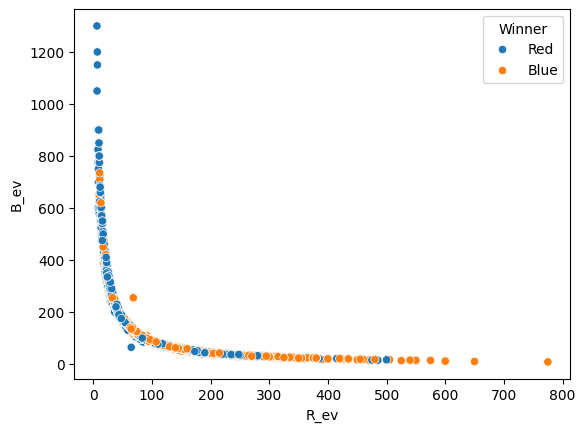

In [ ]:
sns.scatterplot(x='R_ev',y='B_ev',hue = 'Winner', data=df);

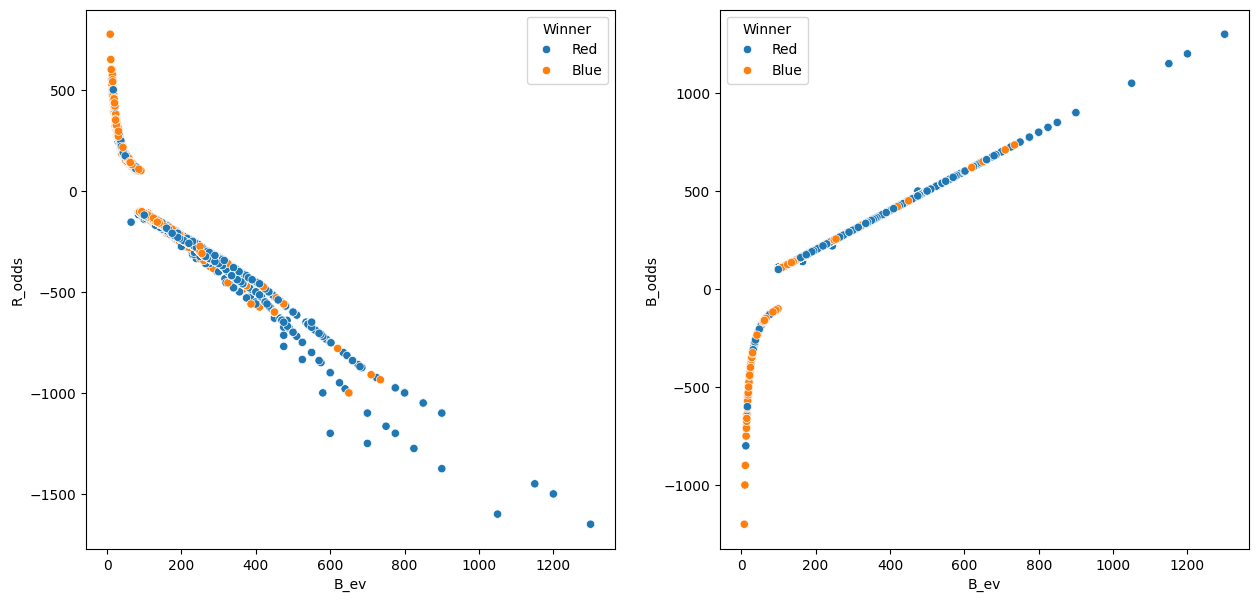

In [ ]:
fig, ax = plt.subplots(1,2, figsize=(15,7))
sns.scatterplot(x='B_ev', y='R_odds',hue = 'Winner', data=df, ax=ax[0]);
sns.scatterplot(x='B_ev', y='B_odds',hue = 'Winner', data=df, ax=ax[1]);
fig.show()

### More Data Cleaning, Feature Engineering.

In [ ]:
df.head()

,R_fighter,B_fighter,R_odds,B_odds,R_ev,B_ev,date,location,country,Winner,title_bout,weight_class,gender,no_of_rounds,B_current_lose_streak,B_current_win_streak,B_draw,B_avg_SIG_STR_landed,B_avg_SIG_STR_pct,B_avg_SUB_ATT,B_avg_TD_landed,B_avg_TD_pct,B_longest_win_streak,B_losses,B_total_rounds_fought,B_total_title_bouts,B_win_by_Decision_Majority,B_win_by_Decision_Split,B_win_by_Decision_Unanimous,B_win_by_KO/TKO,B_win_by_Submission,B_win_by_TKO_Doctor_Stoppage,B_wins,B_Stance,B_Height_cms,B_Reach_cms,B_Weight_lbs,R_current_lose_streak,R_current_win_streak,R_draw,R_avg_SIG_STR_landed,R_avg_SIG_STR_pct,R_avg_SUB_ATT,R_avg_TD_landed,R_avg_TD_pct,R_longest_win_streak,R_losses,R_total_rounds_fought,R_total_title_bouts,R_win_by_Decision_Majority,R_win_by_Decision_Split,R_win_by_Decision_Unanimous,R_win_by_KO/TKO,R_win_by_Submission,R_win_by_TKO_Doctor_Stoppage,R_wins,R_Stance,R_Height_cms,R_Reach_cms,R_Weight_lbs,R_age,B_age,lose_streak_dif,win_streak_dif,longest_win_streak_dif,win_dif,loss_dif,total_round_dif,total_title_bout_dif,ko_dif,sub_dif,height_dif,reach_dif,age_dif,sig_str_dif,avg_sub_att_dif,avg_td_dif,empty_arena,constant_1,B_match_weightclass_rank,R_match_weightclass_rank,R_Women's Flyweight_rank,R_Women's Featherweight_rank,R_Women's Strawweight_rank,R_Women's Bantamweight_rank,R_Heavyweight_rank,R_Light Heavyweight_rank,R_Middleweight_rank,R_Welterweight_rank,R_Lightweight_rank,R_Featherweight_rank,R_Bantamweight_rank,R_Flyweight_rank,R_Pound-for-Pound_rank,B_Women's Flyweight_rank,B_Women's Featherweight_rank,B_Women's Strawweight_rank,B_Women's Bantamweight_rank,B_Heavyweight_rank,B_Light Heavyweight_rank,B_Middleweight_rank,B_Welterweight_rank,B_Lightweight_rank,B_Featherweight_rank,B_Bantamweight_rank,B_Flyweight_rank,B_Pound-for-Pound_rank,better_rank,finish,finish_details,finish_round,finish_round_time,total_fight_time_secs,r_dec_odds,b_dec_odds,r_sub_odds,b_sub_odds,r_ko_odds,b_ko_odds
0,Thiago Santos,Johnny Walker,-150.0,130,66.666667,130.000000,2021-10-02,"Las Vegas, Nevada, USA",USA,Red,False,Light Heavyweight,MALE,5,0,1,0,3.42,0.59,0.7,0.24,1.00,4,2,11,0,0,0,1,4,0,0,5,Orthodox,198.12,208.28,205,3,0,0,3.95,0.48,0.1,0.61,0.36,4,8,43,1,0,0,2,11,0,0,13,Orthodox,187.96,193.04,205,37,29,-3,1,0,-8,-6,-32,-1,-7,0,10.16,15.24,-8,-0.53,0.6,-0.37,1,1,10.0,5.0,NaN,NaN,NaN,NaN,NaN,5.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Red,U-DEC,NaN,5.0,5:00,1500.0,800.0,900.0,2000.0,1600.0,-110.0,175.0
1,Alex Oliveira,Niko Price,170.0,-200,170.000000,50.000000,2021-10-02,"Las Vegas, Nevada, USA",USA,Blue,False,Welterweight,MALE,3,2,0,0,5.16,0.42,0.8,0.79,0.22,2,5,24,0,0,0,0,4,2,0,6,Orthodox,182.88,193.04,170,2,0,0,2.97,0.51,0.5,2.27,0.37,4,8,44,0,0,1,3,4,3,0,11,Orthodox,180.34,193.04,170,33,32,0,0,-2,-5,-3,-20,0,0,-1,2.54,0.00,-1,2.19,0.3,-1.48,1,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,neither,U-DEC,NaN,3.0,5:00,900.0,450.0,350.0,700.0,1100.0,550.0,120.0
2,Misha Cirkunov,Krzysztof Jotko,110.0,-130,110.000000,76.923077,2021-10-02,"Las Vegas, Nevada, USA",USA,Blue,False,Middleweight,MALE,3,1,0,0,2.92,0.41,0.1,1.15,0.34,5,5,38,0,0,2,6,1,0,0,9,Southpaw,185.42,195.58,185,1,0,0,3.77,0.49,1.7,4.48,0.44,4,4,13,0,0,0,0,1,5,0,6,Orthodox,190.50,195.58,205,34,32,0,0,1,3,1,25,0,0,-5,-5.08,0.00,-2,-0.85,-1.6,-3.33,1,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,neither,S-DEC,NaN,3.0,5:00,900.0,550.0,275.0,275.0,1400.0,600.0,185.0
3,Alexander Hernandez,Mike Breeden,-675.0,475,14.814815,475.000000,2021-10-02,"Las Vegas, Nevada, USA",USA,Red,False,Lightweight,MALE,3,1,0,0,4.04,0.34,0.0,0.00,0.00,0,1,3,0,0,0,0,0,0,0,0,Orthodox,177.80,177.80,155,1,0,0,3.79,0.36,0.0,1.57,0.35,2,3,15,0,0,0,2,2,0,0,4,Orthodox,175.26,182.88,155,29,32,0,0,-2,-4,-2,-12,0,-2,0,2.54,-5.08,3,0.25,0.0,-1.57,1,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N

In [ ]:
#Dropping betting odds columns
df.drop('b_ko_odds', axis=1, inplace=True)
df.drop('r_ko_odds', axis=1, inplace=True)
df.drop('b_sub_odds', axis=1, inplace=True)

df.drop('r_sub_odds', axis=1, inplace=True)
df.drop('r_dec_odds', axis=1, inplace=True)
df.drop('b_dec_odds', axis=1, inplace=True)
df.drop('B_match_weightclass_rank', axis=1, inplace=True)

df.drop('finish', axis=1, inplace=True)
df.drop("B_Women's Bantamweight_rank", axis=1, inplace=True)
df.drop("R_match_weightclass_rank", axis=1, inplace=True)
df.drop("R_Women's Flyweight_rank", axis=1, inplace=True)
df.drop("R_Women's Featherweight_rank", axis=1, inplace=True)
df.drop("R_Women's Strawweight_rank", axis=1, inplace=True)
df.drop("R_Women's Bantamweight_rank", axis=1, inplace=True)
df.drop('R_Heavyweight_rank', axis=1, inplace=True)
df.drop('R_Light Heavyweight_rank', axis=1, inplace=True)
df.drop('R_Middleweight_rank', axis=1, inplace=True)
df.drop('R_Welterweight_rank', axis=1, inplace=True)
df.drop("R_Lightweight_rank", axis=1, inplace=True)
df.drop("R_Featherweight_rank", axis=1, inplace=True)
df.drop('R_Bantamweight_rank', axis=1, inplace=True)
df.drop('R_Flyweight_rank', axis=1, inplace=True)
df.drop('R_Pound-for-Pound_rank', axis=1, inplace=True)
df.drop("B_Women's Flyweight_rank", axis=1, inplace=True)
df.drop("B_Women's Featherweight_rank", axis=1, inplace=True)
df.drop("B_Women's Strawweight_rank", axis=1, inplace=True)
df.drop('B_Heavyweight_rank', axis=1, inplace=True)
df.drop('B_Light Heavyweight_rank', axis=1, inplace=True)
df.drop("B_Middleweight_rank", axis=1, inplace=True)
df.drop("B_Welterweight_rank", axis=1, inplace=True)
df.drop('B_Lightweight_rank', axis=1, inplace=True)
df.drop('B_Featherweight_rank', axis=1, inplace=True)
df.drop('B_Bantamweight_rank', axis=1, inplace=True)
df.drop('B_Flyweight_rank', axis=1, inplace=True)
df.drop('B_Pound-for-Pound_rank', axis=1, inplace=True)

df.drop('total_fight_time_secs', axis=1, inplace=True)
df.drop('finish_round_time', axis=1, inplace=True)
df.drop('finish_round', axis=1, inplace=True)

df.drop('finish_details', axis=1, inplace=True)
df.drop('empty_arena', axis=1, inplace=True)
df.drop('location', axis=1, inplace=True)
df.drop('country', axis=1, inplace=True)
df.drop('gender', axis=1, inplace=True)

In [ ]:
for col in df.columns:
    print(col)

R_fighter
B_fighter
R_odds
B_odds
R_ev
B_ev
date
Winner
title_bout
weight_class
no_of_rounds
B_current_lose_streak
B_current_win_streak
B_draw
B_avg_SIG_STR_landed
B_avg_SIG_STR_pct
B_avg_SUB_ATT
B_avg_TD_landed
B_avg_TD_pct
B_longest_win_streak
B_losses
B_total_rounds_fought
B_total_title_bouts
B_win_by_Decision_Majority
B_win_by_Decision_Split
B_win_by_Decision_Unanimous
B_win_by_KO/TKO
B_win_by_Submission
B_win_by_TKO_Doctor_Stoppage
B_wins
B_Stance
B_Height_cms
B_Reach_cms
B_Weight_lbs
R_current_lose_streak
R_current_win_streak
R_draw
R_avg_SIG_STR_landed
R_avg_SIG_STR_pct
R_avg_SUB_ATT
R_avg_TD_landed
R_avg_TD_pct
R_longest_win_streak
R_losses
R_total_rounds_fought
R_total_title_bouts
R_win_by_Decision_Majority
R_win_by_Decision_Split
R_win_by_Decision_Unanimous
R_win_by_KO/TKO
R_win_by_Submission
R_win_by_TKO_Doctor_Stoppage
R_wins
R_Stance
R_Height_cms
R_Reach_cms
R_Weight_lbs
R_age
B_age
lose_streak_dif
win_streak_dif
longest_win_streak_dif
win_dif
loss_dif
total_round_dif
tota

In [ ]:
df['loss_dif'] = df['B_losses'] - df['R_losses']
df['age_dif'] = df['B_age'] - df['R_age']
df['sig_str_land_dif'] = df['B_avg_SIG_STR_landed'] - df['R_avg_SIG_STR_landed']
df['lose_streak_dif'] = df['B_current_lose_streak'] - df['R_current_lose_streak']
df['win_streak_dif'] = df['B_current_win_streak'] - df['R_current_win_streak']
df['longest_win_streak_dif'] = df['B_longest_win_streak'] - df['R_longest_win_streak']
df['total_round_dif'] = df['B_total_rounds_fought'] - df['R_total_rounds_fought']
df['height_dif'] = df['B_Height_cms'] - df['R_Height_cms']
df['reach_dif'] = df['B_Reach_cms'] - df['R_Reach_cms']
df['avg_sub_att_dif'] = df['B_avg_SUB_ATT'] - df['R_avg_SUB_ATT']
df['avg_td_landed_dif'] = df['B_avg_TD_landed'] - df['R_avg_TD_landed']
df['Avg_TD_pct_dif'] = df['B_avg_TD_pct'] - df['R_avg_TD_pct']
df['avg_SIG_STR_pct_dif'] = df['B_avg_SIG_STR_pct'] - df['R_avg_SIG_STR_pct']

In [ ]:
df['draw_diff'] = (df['B_draw']-df['R_draw'])
df['odds_diff'] = (df['B_odds']-df['R_odds'])
df['ev_diff'] = (df['B_ev']-df['R_ev'])
df['sig_str_landed_diff']=(df['B_avg_SIG_STR_landed']-df['R_avg_SIG_STR_landed'])

In [ ]:
for col in df.columns:
    print(col)

R_fighter
B_fighter
R_odds
B_odds
R_ev
B_ev
date
Winner
title_bout
weight_class
no_of_rounds
B_current_lose_streak
B_current_win_streak
B_draw
B_avg_SIG_STR_landed
B_avg_SIG_STR_pct
B_avg_SUB_ATT
B_avg_TD_landed
B_avg_TD_pct
B_longest_win_streak
B_losses
B_total_rounds_fought
B_total_title_bouts
B_win_by_Decision_Majority
B_win_by_Decision_Split
B_win_by_Decision_Unanimous
B_win_by_KO/TKO
B_win_by_Submission
B_win_by_TKO_Doctor_Stoppage
B_wins
B_Stance
B_Height_cms
B_Reach_cms
B_Weight_lbs
R_current_lose_streak
R_current_win_streak
R_draw
R_avg_SIG_STR_landed
R_avg_SIG_STR_pct
R_avg_SUB_ATT
R_avg_TD_landed
R_avg_TD_pct
R_longest_win_streak
R_losses
R_total_rounds_fought
R_total_title_bouts
R_win_by_Decision_Majority
R_win_by_Decision_Split
R_win_by_Decision_Unanimous
R_win_by_KO/TKO
R_win_by_Submission
R_win_by_TKO_Doctor_Stoppage
R_wins
R_Stance
R_Height_cms
R_Reach_cms
R_Weight_lbs
R_age
B_age
lose_streak_dif
win_streak_dif
longest_win_streak_dif
win_dif
loss_dif
total_round_dif
tota

In [ ]:
var_drop = [
'B_odds',
'R_odds',
'B_ev',
'R_ev',
'B_current_lose_streak', 'R_current_lose_streak',
'B_current_win_streak', 'R_current_win_streak',
'B_longest_win_streak', 'R_longest_win_streak',
'B_wins', 'R_wins',
'B_losses', 'R_losses',
'B_total_rounds_fought', 'R_total_rounds_fought',
'B_total_title_bouts', 'R_total_title_bouts',
'B_win_by_KO/TKO', 'R_win_by_KO/TKO',
'B_win_by_Submission', 'R_win_by_Submission',
'B_Height_cms', 'R_Height_cms',
'B_Reach_cms', 'R_Reach_cms',
'B_age', 'R_age',
'B_avg_SIG_STR_landed', 'R_avg_SIG_STR_landed',
'B_avg_SUB_ATT', 'R_avg_SUB_ATT',
'B_avg_TD_landed', 'R_avg_TD_landed',
'B_draw','B_avg_SIG_STR_pct','B_avg_TD_pct','B_win_by_Decision_Majority','B_win_by_Decision_Split','B_win_by_Decision_Unanimous','B_win_by_TKO_Doctor_Stoppage',
'R_draw','R_avg_SIG_STR_pct','R_avg_TD_pct','R_win_by_Decision_Majority','R_win_by_Decision_Split','R_win_by_Decision_Unanimous','R_win_by_TKO_Doctor_Stoppage']
df.drop(var_drop, axis=1, inplace = True)

In [ ]:
for col in df.columns:
    print(col)

R_fighter
B_fighter
date
Winner
title_bout
weight_class
no_of_rounds
B_Stance
B_Weight_lbs
R_Stance
R_Weight_lbs
lose_streak_dif
win_streak_dif
longest_win_streak_dif
win_dif
loss_dif
total_round_dif
total_title_bout_dif
ko_dif
sub_dif
height_dif
reach_dif
age_dif
sig_str_dif
avg_sub_att_dif
avg_td_dif
constant_1
better_rank
sig_str_land_dif
avg_td_landed_dif
Avg_TD_pct_dif
avg_SIG_STR_pct_dif
draw_diff
odds_diff
ev_diff
sig_str_landed_diff


In [ ]:
comm_drop = [
'date','weight_class','B_Weight_lbs','R_Weight_lbs'
]
df.drop(comm_drop, axis=1, inplace = True)

In [ ]:
#spelling mistake
df['B_Stance'].loc[df['B_Stance']=='Switch '] = 'Switch'

<ipython-input-38-01c612fa9e1e>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['B_Stance'].loc[df['B_Stance']=='Switch '] = 'Switch'


In [ ]:
stance = ['B_Stance', 'R_Stance']

In [ ]:
for x in stance:
    df[x] = [4 if st == 'Orthodox'
                           else 3 if st == 'Southpaw'
                           else 2 if st == 'Switch'
                           else 1 for st in df[x]]
#using -1 and 1 for both red and blue so there is no misunderstanding that one variable is better than the other
df['better_rank'] = [-1 if rank == 'Red'
                               else 1 if rank == 'Blue'
                               else 0 for rank in df['better_rank']]

df['title_bout'] = [1 if tb==True else 0 for tb in df['title_bout']]

In [ ]:
df['Stance_diff'] = (df['B_Stance'] - df['R_Stance'])
df.drop(stance, axis = 1, inplace = True)

In [ ]:
df.head()

,R_fighter,B_fighter,Winner,title_bout,no_of_rounds,lose_streak_dif,win_streak_dif,longest_win_streak_dif,win_dif,loss_dif,total_round_dif,total_title_bout_dif,ko_dif,sub_dif,height_dif,reach_dif,age_dif,sig_str_dif,avg_sub_att_dif,avg_td_dif,constant_1,better_rank,sig_str_land_dif,avg_td_landed_dif,Avg_TD_pct_dif,avg_SIG_STR_pct_dif,draw_diff,odds_diff,ev_diff,sig_str_landed_diff,Stance_diff
0,Thiago Santos,Johnny Walker,Red,0,5,-3,1,0,-8,-6,-32,-1,-7,0,10.16,15.24,-8,-0.53,0.6,-0.37,1,-1,-0.53,-0.37,0.64,0.11,0,280.0,63.333333,-0.53,0
1,Alex Oliveira,Niko Price,Blue,0,3,0,0,-2,-5,-3,-20,0,0,-1,2.54,0.00,-1,2.19,0.3,-1.48,1,0,2.19,-1.48,-0.15,-0.09,0,-370.0,-120.000000,2.19,0
2,Misha Cirkunov,Krzysztof Jotko,Blue,0,3,0,0,1,3,1,25,0,0,-5,-5.08,0.00,-2,-0.85,-1.6,-3.33,1,0,-0.85,-3.33,-0.10,-0.08,0,-240.0,-33.076923,-0.85,-1
3,Alexander Hernandez,Mike Breeden,Red,0,3,0,0,-2,-4,-2,-12,0,-2,0,2.54,-5.08,3,0.25,0.0,-1.57,1,0,0.25,-1.57,-0.35,-0.02,0,1150.0,460.185185,0.25,0
4,Joe Solecki,Jared Gordon,Blue,0,3,0,-2,-2,1,3,11,0,1,-2,0.00,-5.08,5,2.58,-0.6,-0.31,1,0,2.58,-0.31,-0.13,-0.06,0,250.0,40.925926,2.58,0


In [ ]:
num_columns = len(df.columns)
print("Number of columns in the DataFrame:", num_columns)

Number of columns in the DataFrame: 31


In [ ]:
df.head()

,R_fighter,B_fighter,Winner,title_bout,no_of_rounds,lose_streak_dif,win_streak_dif,longest_win_streak_dif,win_dif,loss_dif,total_round_dif,total_title_bout_dif,ko_dif,sub_dif,height_dif,reach_dif,age_dif,sig_str_dif,avg_sub_att_dif,avg_td_dif,constant_1,better_rank,sig_str_land_dif,avg_td_landed_dif,Avg_TD_pct_dif,avg_SIG_STR_pct_dif,draw_diff,odds_diff,ev_diff,sig_str_landed_diff,Stance_diff
0,Thiago Santos,Johnny Walker,Red,0,5,-3,1,0,-8,-6,-32,-1,-7,0,10.16,15.24,-8,-0.53,0.6,-0.37,1,-1,-0.53,-0.37,0.64,0.11,0,280.0,63.333333,-0.53,0
1,Alex Oliveira,Niko Price,Blue,0,3,0,0,-2,-5,-3,-20,0,0,-1,2.54,0.00,-1,2.19,0.3,-1.48,1,0,2.19,-1.48,-0.15,-0.09,0,-370.0,-120.000000,2.19,0
2,Misha Cirkunov,Krzysztof Jotko,Blue,0,3,0,0,1,3,1,25,0,0,-5,-5.08,0.00,-2,-0.85,-1.6,-3.33,1,0,-0.85,-3.33,-0.10,-0.08,0,-240.0,-33.076923,-0.85,-1
3,Alexander Hernandez,Mike Breeden,Red,0,3,0,0,-2,-4,-2,-12,0,-2,0,2.54,-5.08,3,0.25,0.0,-1.57,1,0,0.25,-1.57,-0.35,-0.02,0,1150.0,460.185185,0.25,0
4,Joe Solecki,Jared Gordon,Blue,0,3,0,-2,-2,1,3,11,0,1,-2,0.00,-5.08,5,2.58,-0.6,-0.31,1,0,2.58,-0.31,-0.13,-0.06,0,250.0,40.925926,2.58,0


### Random Forest(Title Fights)

In [ ]:
#Encoding label so it is easier to find correlation
df['Winner'] = [1 if winner == 'Red' else 0 for winner in df.Winner]

In [ ]:
title_df = df[df['title_bout'] == 1]

In [ ]:
label = title_df.Winner
title_df.drop(['Winner'], axis=1, inplace = True)

<ipython-input-47-eeeace572fe1>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  title_df.drop(['Winner'], axis=1, inplace = True)


In [ ]:
#Encoding the remaining categorical variables
cat_col = ['R_fighter', 'B_fighter']
enc = LabelEncoder()
for i in title_df[cat_col]:
    title_df[i] = enc.fit_transform(title_df[i])

<ipython-input-48-d6d58ac5ba77>:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  title_df[i] = enc.fit_transform(title_df[i])
<ipython-input-48-d6d58ac5ba77>:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  title_df[i] = enc.fit_transform(title_df[i])


In [ ]:
X_train, X_valid, y_train, y_valid = train_test_split(title_df, label, test_size = 0.3, random_state=1)

In [ ]:
impute = SimpleImputer(strategy = 'mean')
impute.fit(X_train)
X_train = impute.transform(X_train)
X_valid = impute.transform(X_valid)

In [ ]:
RF_model = RandomForestClassifier(random_state=1)

In [ ]:
RF_model.fit(X_train, y_train)

RandomForestClassifier(random_state=1)

In [ ]:
preds = RF_model.predict(X_valid)
accuracy_score(y_valid, preds)

0.8275862068965517

In [ ]:
# Calculate precision
precision = precision_score(y_valid, preds)

# Calculate recall
recall = recall_score(y_valid, preds)

#Calculate Accuracy
accur = accuracy_score(y_valid, preds)

# Calculate Mean Squared Error (MSE)
mse = mean_squared_error(y_valid, preds)

# Calculate Mean Absolute Error (MAE)
mae = mean_absolute_error(y_valid, preds)

# Calculate F1 score
f1 = f1_score(y_valid, preds)

print("F1 Score:", f1)
print("Mean Squared Error (MSE):", mse)
print("Mean Absolute Error (MAE):", mae)
print("Precision:", precision)
print("Recall:", recall)
print("Accuracy:", accur)

F1 Score: 0.8837209302325582
Mean Squared Error (MSE): 0.1724137931034483
Mean Absolute Error (MAE): 0.1724137931034483
Precision: 0.8444444444444444
Recall: 0.926829268292683
Accuracy: 0.8275862068965517


### Custom LR(Title Fights)

In [ ]:
class LogisticRegressionCustom:
    def __init__(self, learning_rate=0.01, num_iterations=9999):
        self.learning_rate = learning_rate
        self.num_iterations = num_iterations
        self.weights = None
        self.bias = None

    def sigmoid(self, z):
        z = np.clip(z, -500, 500)
        return 1 / (1 + np.exp(-z))

    def fit(self, X, y):
        num_samples, num_features = X.shape
        self.weights = np.zeros(num_features)
        self.bias = 0

        # Gradient descent
        for _ in range(self.num_iterations):
            linear_model = np.dot(X, self.weights) + self.bias
            y_predicted = self.sigmoid(linear_model)

            # Compute gradients
            dw = (1 / num_samples) * np.dot(X.T, (y_predicted - y))
            db = (1 / num_samples) * np.sum(y_predicted - y)

            # Update parameters
            self.weights -= self.learning_rate * dw
            self.bias -= self.learning_rate * db

    def predict(self, X):
        linear_model = np.dot(X, self.weights) + self.bias
        y_predicted = self.sigmoid(linear_model)
        y_predicted_cls = [1 if i > 0.5 else 0 for i in y_predicted]
        return y_predicted_cls

model = LogisticRegressionCustom(learning_rate=0.01, num_iterations=9999)

# Train the model
model.fit(X_train, y_train)

# Make predictions using your custom model
preds = model.predict(X_valid)

In [ ]:
# Calculate precision
precision = precision_score(y_valid, preds)

# Calculate recall
recall = recall_score(y_valid, preds)

#Calculate Accuracy
accur = accuracy_score(y_valid, preds)

# Calculate Mean Squared Error (MSE)
mse = mean_squared_error(y_valid, preds)

# Calculate Mean Absolute Error (MAE)
mae = mean_absolute_error(y_valid, preds)

# Calculate F1 score
f1 = f1_score(y_valid, preds)

print("F1 Score:", f1)
print("Mean Squared Error (MSE):", mse)
print("Mean Absolute Error (MAE):", mae)
print("Precision:", precision)
print("Recall:", recall)
print("Accuracy:", accur)

F1 Score: 0.8666666666666666
Mean Squared Error (MSE): 0.20689655172413793
Mean Absolute Error (MAE): 0.20689655172413793
Precision: 0.7959183673469388
Recall: 0.9512195121951219
Accuracy: 0.7931034482758621


###Logistic Regression(Title Fights)

In [ ]:
# Initialize and train the logistic regression model
logistic_model = LogisticRegression(random_state=1, max_iter=1000)
logistic_model.fit(X_train, y_train)

# Make predictions on the validation set
preds = logistic_model.predict(X_valid)

# Calculate accuracy
accuracy = accuracy_score(y_valid, preds)
print("Accuracy:", accuracy)

Accuracy: 0.8103448275862069


/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
# Calculate precision
precision = precision_score(y_valid, preds)

# Calculate recall
recall = recall_score(y_valid, preds)

#Calculate Accuracy
accur = accuracy_score(y_valid, preds)

# Calculate Mean Squared Error (MSE)
mse = mean_squared_error(y_valid, preds)

# Calculate Mean Absolute Error (MAE)
mae = mean_absolute_error(y_valid, preds)

# Calculate F1 score
f1 = f1_score(y_valid, preds)

print("F1 Score:", f1)
print("Mean Squared Error (MSE):", mse)
print("Mean Absolute Error (MAE):", mae)
print("Precision:", precision)
print("Recall:", recall)
print("Accuracy:", accur)

F1 Score: 0.8674698795180722
Mean Squared Error (MSE): 0.1896551724137931
Mean Absolute Error (MAE): 0.1896551724137931
Precision: 0.8571428571428571
Recall: 0.8780487804878049
Accuracy: 0.8103448275862069


In [ ]:
title_df_imputed = impute.fit_transform(title_df)

# Perform cross-validation
scores = cross_val_score(RF_model, title_df_imputed, label, cv=5)  # cv=5 means 5-fold cross-validation

# Print the cross-validation scores
print("Cross-Validation Scores:", scores)
print("Mean Accuracy:", scores.mean())

Cross-Validation Scores: [0.74358974 0.53846154 0.65789474 0.65789474 0.81578947]
Mean Accuracy: 0.6827260458839406


###GDB(Title Fights)

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, recall_score, precision_score

# Initialize and train the Gradient Boosting model
gb_model = GradientBoostingClassifier(random_state=1)
gb_model.fit(X_train, y_train)

# Make predictions on the validation set
gb_preds = gb_model.predict(X_valid)

# Calculate accuracy
gb_accuracy = accuracy_score(y_valid, gb_preds)
print("Gradient Boosting Accuracy:", gb_accuracy)

# Calculate recall and precision
recall = recall_score(y_valid, gb_preds)
precision = precision_score(y_valid, gb_preds)
print("Recall:", recall)
print("Precision:", precision)


Gradient Boosting Accuracy: 0.7758620689655172
Recall: 0.8780487804878049
Precision: 0.8181818181818182


In [ ]:
# Calculate precision
precision = precision_score(y_valid, gb_preds)

# Calculate recall
recall = recall_score(y_valid, gb_preds)

#Calculate Accuracy
accur = accuracy_score(y_valid, gb_preds)

# Calculate Mean Squared Error (MSE)
mse = mean_squared_error(y_valid, gb_preds)

# Calculate Mean Absolute Error (MAE)
mae = mean_absolute_error(y_valid, gb_preds)

# Calculate F1 score
f1 = f1_score(y_valid, gb_preds)

print("F1 Score:", f1)
print("Mean Squared Error (MSE):", mse)
print("Mean Absolute Error (MAE):", mae)
print("Precision:", precision)
print("Recall:", recall)
print("Accuracy:", accur)

F1 Score: 0.8470588235294119
Mean Squared Error (MSE): 0.22413793103448276
Mean Absolute Error (MAE): 0.22413793103448276
Precision: 0.8181818181818182
Recall: 0.8780487804878049
Accuracy: 0.7758620689655172


###RF on whole model

In [ ]:
label = df.Winner
df.drop(['Winner'], axis=1, inplace = True)

In [ ]:
#Encoding the remaining categorical variables
cat_col = ['R_fighter', 'B_fighter']
enc = LabelEncoder()
for i in df[cat_col]:
    df[i] = enc.fit_transform(df[i])

In [ ]:
X_train, X_valid, y_train, y_valid = train_test_split(df, label, test_size = 0.3, random_state=1)

In [ ]:
#At this point all the null values are the ones that have been left empty by error/mistake and are not left empty deliberately.
#So, it would make sense to fill in these with mean rather than 0 or anything else
impute = SimpleImputer(strategy = 'mean')
impute.fit(X_train)
X_train = impute.transform(X_train)
X_valid = impute.transform(X_valid)

In [ ]:
RF_model = RandomForestClassifier(random_state=1)

In [ ]:
RF_model.fit(X_train, y_train)

RandomForestClassifier(random_state=1)

In [ ]:
# Drop the 'Winner' column from the first row for prediction
row_to_predict = df.iloc[[0]]

# Impute missing values with the mean
row_to_predict = impute.transform(row_to_predict.values.reshape(1, -1))

# Make prediction for the specific row
prediction = RF_model.predict(row_to_predict)

# Display the predicted winner
print("Predicted Winner:", prediction[0])

#

Predicted Winner: 1


/usr/local/lib/python3.10/dist-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but SimpleImputer was fitted with feature names
  warnings.warn(


In [ ]:
preds = RF_model.predict(X_valid)
accuracy_score(y_valid, preds)

0.6474164133738601

In [ ]:
# Calculate precision
precision = precision_score(y_valid, preds)

# Calculate recall
recall = recall_score(y_valid, preds)

#Calculate Accuracy
accur = accuracy_score(y_valid, preds)

# Calculate Mean Squared Error (MSE)
mse = mean_squared_error(y_valid, preds)

# Calculate Mean Absolute Error (MAE)
mae = mean_absolute_error(y_valid, preds)

# Calculate F1 score
f1 = f1_score(y_valid, preds)

print("F1 Score:", f1)
print("Mean Squared Error (MSE):", mse)
print("Mean Absolute Error (MAE):", mae)
print("Precision:", precision)
print("Recall:", recall)
print("Accuracy:", accur)

F1 Score: 0.70595690747782
Mean Squared Error (MSE): 0.3525835866261398
Mean Absolute Error (MAE): 0.3525835866261398
Precision: 0.6936488169364882
Recall: 0.7187096774193549
Accuracy: 0.6474164133738601


from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

Visualize one of the decision trees in the Random Forest
plt.figure(figsize=(12, 8))
plot_tree(RF_model.estimators_[0], feature_names=df.columns, class_names=['Not Winner', 'Winner'], filled=True, rounded=True)
plt.show()

In [ ]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

# Visualize one of the decision trees in the Random Forest
#plt.figure(figsize=(12, 8))
#plot_tree(RF_model.estimators_[0], feature_names=df.columns, class_names=['Not Winner', 'Winner'], filled=True, rounded=True)
#plt.show()

### LR on Whole Model


In [ ]:
X_train, X_valid, y_train, y_valid = train_test_split(df, label, test_size = 0.3, random_state=1)

In [ ]:
impute = SimpleImputer(strategy = 'mean')
impute.fit(X_train)
X_train = impute.transform(X_train)
X_valid = impute.transform(X_valid)

In [ ]:
# Initialize and train the logistic regression model
logistic_model = LogisticRegression(random_state=1, max_iter=9999)
logistic_model.fit(X_train, y_train)

# Make predictions on the validation set
preds = logistic_model.predict(X_valid)

# Calculate accuracy
accuracy = accuracy_score(y_valid, preds)
print("Accuracy:", accuracy)

Accuracy: 0.6603343465045592


In [ ]:
# Calculate precision
precision = precision_score(y_valid, preds)

# Calculate recall
recall = recall_score(y_valid, preds)

#Calculate Accuracy
accur = accuracy_score(y_valid, preds)

# Calculate Mean Squared Error (MSE)
mse = mean_squared_error(y_valid, preds)

# Calculate Mean Absolute Error (MAE)
mae = mean_absolute_error(y_valid, preds)

# Calculate F1 score
f1 = f1_score(y_valid, preds)

print("F1 Score:", f1)
print("Mean Squared Error (MSE):", mse)
print("Mean Absolute Error (MAE):", mae)
print("Precision:", precision)
print("Recall:", recall)
print("Accuracy:", accur)

F1 Score: 0.732495511669659
Mean Squared Error (MSE): 0.33966565349544076
Mean Absolute Error (MAE): 0.33966565349544076
Precision: 0.6830357142857143
Recall: 0.7896774193548387
Accuracy: 0.6603343465045592


### GDB on whole model

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, recall_score, precision_score

# Initialize and train the Gradient Boosting model
gb_model = GradientBoostingClassifier(random_state=1)
gb_model.fit(X_train, y_train)

# Make predictions on the validation set
gb_preds = gb_model.predict(X_valid)

# Calculate accuracy
gb_accuracy = accuracy_score(y_valid, gb_preds)
print("Gradient Boosting Accuracy:", gb_accuracy)

# Calculate recall and precision
recall = recall_score(y_valid, gb_preds)
precision = precision_score(y_valid, gb_preds)
print("Recall:", recall)
print("Precision:", precision)

Gradient Boosting Accuracy: 0.6458966565349544
Recall: 0.7367741935483871
Precision: 0.6854741896758704


In [ ]:
# Calculate precision
precision = precision_score(y_valid, gb_preds)

# Calculate recall
recall = recall_score(y_valid, gb_preds)

#Calculate Accuracy
accur = accuracy_score(y_valid, gb_preds)

# Calculate Mean Squared Error (MSE)
mse = mean_squared_error(y_valid, gb_preds)

# Calculate Mean Absolute Error (MAE)
mae = mean_absolute_error(y_valid, gb_preds)

# Calculate F1 score
f1 = f1_score(y_valid, gb_preds)

print("F1 Score:", f1)
print("Mean Squared Error (MSE):", mse)
print("Mean Absolute Error (MAE):", mae)
print("Precision:", precision)
print("Recall:", recall)
print("Accuracy:", accur)

F1 Score: 0.7101990049751244
Mean Squared Error (MSE): 0.3541033434650456
Mean Absolute Error (MAE): 0.3541033434650456
Precision: 0.6854741896758704
Recall: 0.7367741935483871
Accuracy: 0.6458966565349544


### Custom LR(Whole Dataset)

In [ ]:
class LogisticRegressionCustom:
    def __init__(self, learning_rate=0.01, num_iterations=1000):
        self.learning_rate = learning_rate
        self.num_iterations = num_iterations
        self.weights = None
        self.bias = None

    def sigmoid(self, z):
        z = np.clip(z, -500, 500)
        return 1 / (1 + np.exp(-z))

    def fit(self, X, y):
        num_samples, num_features = X.shape
        self.weights = np.zeros(num_features)
        self.bias = 0

        # Gradient descent
        for _ in range(self.num_iterations):
            linear_model = np.dot(X, self.weights) + self.bias
            y_predicted = self.sigmoid(linear_model)

            # Compute gradients
            dw = (1 / num_samples) * np.dot(X.T, (y_predicted - y))
            db = (1 / num_samples) * np.sum(y_predicted - y)

            # Update parameters
            self.weights -= self.learning_rate * dw
            self.bias -= self.learning_rate * db

    def predict(self, X):
        linear_model = np.dot(X, self.weights) + self.bias
        y_predicted = self.sigmoid(linear_model)
        y_predicted_cls = [1 if i > 0.5 else 0 for i in y_predicted]
        return y_predicted_cls

model = LogisticRegressionCustom(learning_rate=0.01, num_iterations=1000)

# Train the model
model.fit(X_train, y_train)

# Make predictions using your custom model
preds = model.predict(X_valid)

In [ ]:
# Calculate precision
precision = precision_score(y_valid, preds)

# Calculate recall
recall = recall_score(y_valid, preds)

#Calculate Accuracy
accur = accuracy_score(y_valid, preds)

# Calculate Mean Squared Error (MSE)
mse = mean_squared_error(y_valid, preds)

# Calculate Mean Absolute Error (MAE)
mae = mean_absolute_error(y_valid, preds)

# Calculate F1 score
f1 = f1_score(y_valid, preds)

print("F1 Score:", f1)
print("Mean Squared Error (MSE):", mse)
print("Mean Absolute Error (MAE):", mae)
print("Precision:", precision)
print("Recall:", recall)
print("Accuracy:", accur)

F1 Score: 0.6278366111951588
Mean Squared Error (MSE): 0.3738601823708207
Mean Absolute Error (MAE): 0.3738601823708207
Precision: 0.7586837294332724
Recall: 0.535483870967742
Accuracy: 0.6261398176291794
